# Phase 3: Behavioral Feedback Analysis
Compare 3 feedback formats (neutral, directional, comparative) across all 10 selected behavioral features.
29 conditions × 5 seeds = 145 runs, 100 candidates each, using gemini-3-flash.

Note: `longest_no_improvement_streak` excluded from comparative (U-shaped AOCC relationship).

In [1]:
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Add repo root to path so we can import experiments.*
sys.path.insert(0, str(Path("..").resolve()))

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

# --- Constants ---
RESULTS_DIR = Path("../results_phase3")
BUDGET = 100
N_SEEDS = 5
N_INSTANCES = 10
EVAL_SEEDS = 5

FEATURES = [
    "avg_improvement",
    "intensification_ratio",
    "fitness_plateau_fraction",
    "step_size_autocorrelation",
    "improvement_spatial_correlation",
    "half_convergence_time",
    "fitness_autocorrelation",
    "x_spread_early",
    "longest_no_improvement_streak",
    "dimension_convergence_heterogeneity",
]

FORMATS = ["neutral", "directional", "comparative"]
COMPARATIVE_EXCLUDE = {"longest_no_improvement_streak"}

# Build 29 conditions (longest_no_improvement_streak has no comparative)
CONDITIONS = []
for feat in FEATURES:
    for fmt in FORMATS:
        if fmt == "comparative" and feat in COMPARATIVE_EXCLUDE:
            continue
        CONDITIONS.append(f"{fmt}-{feat}")

def formats_for_feature(feat):
    """Return list of formats available for a given feature."""
    if feat in COMPARATIVE_EXCLUDE:
        return ["neutral", "directional"]
    return FORMATS

# Colors
FORMAT_COLORS = {
    "neutral": "#1f77b4",
    "directional": "#ff7f0e",
    "comparative": "#2ca02c",
}
FEATURE_SHORT = {
    "avg_improvement": "avg_impr",
    "intensification_ratio": "intens_ratio",
    "fitness_plateau_fraction": "plateau_frac",
    "step_size_autocorrelation": "step_autocorr",
    "improvement_spatial_correlation": "impr_spatial",
    "half_convergence_time": "half_conv",
    "fitness_autocorrelation": "fit_autocorr",
    "x_spread_early": "x_spread",
    "longest_no_improvement_streak": "no_impr_streak",
    "dimension_convergence_heterogeneity": "dim_conv_het",
}

# --- Load all results ---
def parse_fitness(val):
    try:
        f = float(val)
        return f if not (math.isinf(f) and f < 0) else np.nan
    except (TypeError, ValueError):
        return np.nan

def load_all():
    rows = []
    for cond in CONDITIONS:
        parts = cond.split("-", 1)
        fmt, feat = parts[0], parts[1]
        for seed in range(N_SEEDS):
            seed_dir = RESULTS_DIR / cond / f"seed-{seed}"
            run_dirs = sorted(seed_dir.glob("run-*"))
            if not run_dirs:
                continue
            log_file = run_dirs[0] / "log.jsonl"
            if not log_file.exists():
                continue
            with open(log_file) as f:
                for i, line in enumerate(f):
                    entry = json.loads(line.strip())
                    fitness = parse_fitness(entry.get("fitness"))
                    meta = entry.get("metadata", {})
                    aucs = meta.get("aucs", [])
                    rows.append({
                        "condition": cond,
                        "format": fmt,
                        "feature": feat,
                        "seed": seed,
                        "evaluation": i,
                        "fitness": fitness,
                        "failed": np.isnan(fitness),
                        "name": entry.get("name", ""),
                        "aucs": aucs,
                        "auc_mean": np.mean(aucs) if aucs else np.nan,
                        "generation": entry.get("generation", 0),
                    })
    df = pd.DataFrame(rows)
    return df

df = load_all()
print(f"Loaded {len(df)} evaluations across {df['condition'].nunique()} conditions")
print(f"\nEvaluations per condition:")
print(df.groupby("condition").size().to_string())

Loaded 14500 evaluations across 29 conditions

Evaluations per condition:
condition
comparative-avg_improvement                        500
comparative-dimension_convergence_heterogeneity    500
comparative-fitness_autocorrelation                500
comparative-fitness_plateau_fraction               500
comparative-half_convergence_time                  500
comparative-improvement_spatial_correlation        500
comparative-intensification_ratio                  500
comparative-step_size_autocorrelation              500
comparative-x_spread_early                         500
directional-avg_improvement                        500
directional-dimension_convergence_heterogeneity    500
directional-fitness_autocorrelation                500
directional-fitness_plateau_fraction               500
directional-half_convergence_time                  500
directional-improvement_spatial_correlation        500
directional-intensification_ratio                  500
directional-longest_no_improvement_s

## 1. AOCC Summary: Format x Feature

Mean Best AOCC per condition (5 seeds):


format,comparative,directional,neutral
feature,,,
avg_improvement,0.8595,0.8664,0.8826
dimension_convergence_heterogeneity,0.7788,0.7877,0.9049
fitness_autocorrelation,0.7495,0.8143,0.8405
fitness_plateau_fraction,0.8111,0.8743,0.8913
half_convergence_time,0.7580,0.8621,0.8474
improvement_spatial_correlation,0.7855,0.8572,0.8530
intensification_ratio,0.7211,0.8059,0.9072
longest_no_improvement_streak,—,0.8604,0.7889
step_size_autocorrelation,0.7614,0.7975,0.8100


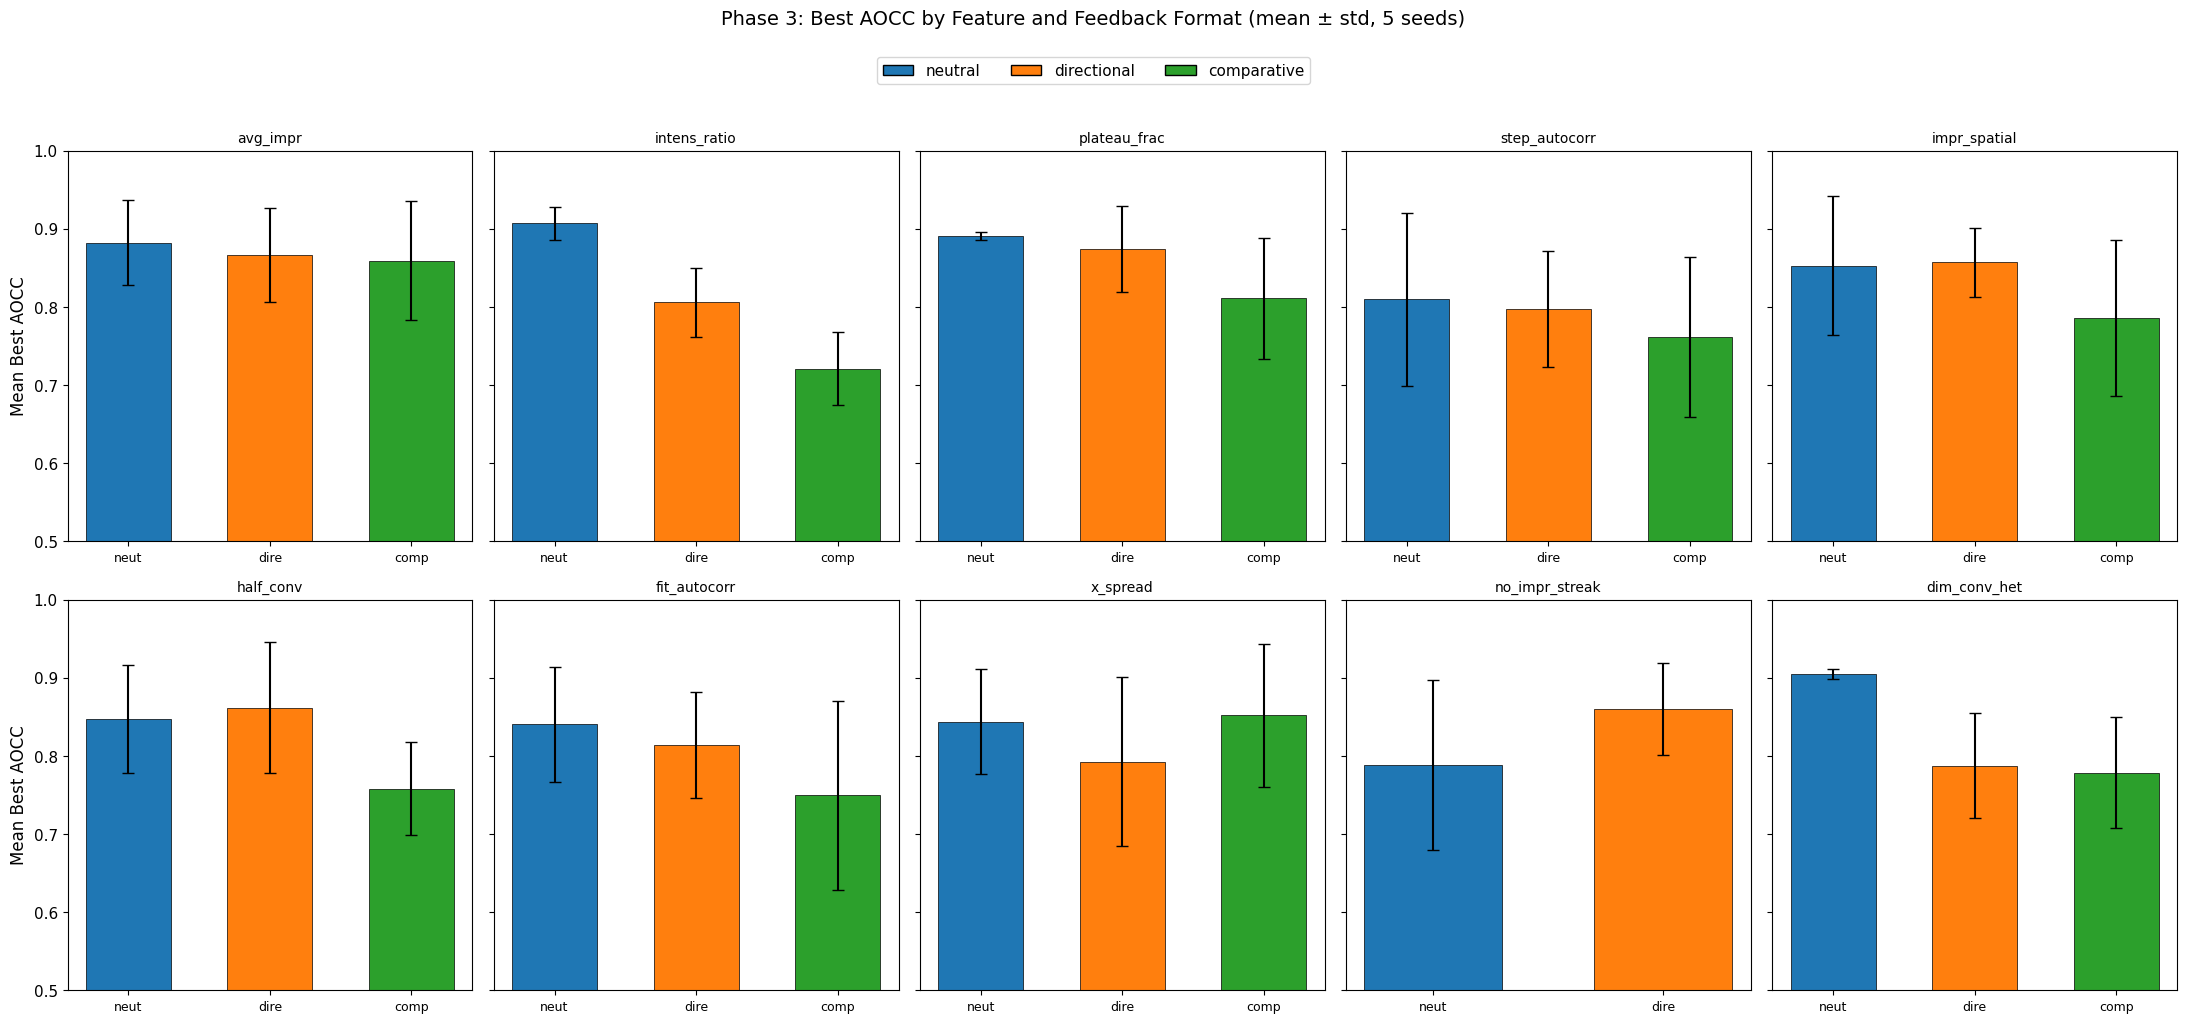

In [2]:
# Best AOCC per (condition, seed)
best = df.groupby(["condition", "format", "feature", "seed"])["fitness"].max().reset_index()
best.columns = ["condition", "format", "feature", "seed", "best_aocc"]

# Summary table: mean/std best AOCC per condition
summary = best.groupby(["feature", "format"])["best_aocc"].agg(["mean", "std"]).reset_index()
summary.columns = ["feature", "format", "aocc_mean", "aocc_std"]

# Pivot for display
pivot_mean = summary.pivot(index="feature", columns="format", values="aocc_mean")
pivot_std = summary.pivot(index="feature", columns="format", values="aocc_std")

print("Mean Best AOCC per condition (5 seeds):")
display(pivot_mean.style.format("{:.4f}", na_rep="—").background_gradient(cmap="RdYlGn", vmin=0.6, vmax=0.95, axis=None))

# Grouped bar chart — 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=True)
axes_flat = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    fmts = formats_for_feature(feat)
    x = np.arange(len(fmts))
    vals = [pivot_mean.loc[feat, f] if f in pivot_mean.columns and feat in pivot_mean.index else 0 for f in fmts]
    errs = [pivot_std.loc[feat, f] if f in pivot_std.columns and feat in pivot_std.index else 0 for f in fmts]
    colors = [FORMAT_COLORS[f] for f in fmts]
    ax.bar(x, vals, yerr=errs, color=colors, edgecolor="black", linewidth=0.5, capsize=4, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:4] for f in fmts], fontsize=9)
    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    ax.set_ylim(0.5, 1.0)
    if idx % 5 == 0:
        ax.set_ylabel("Mean Best AOCC")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=FORMAT_COLORS[f], edgecolor="black", label=f) for f in FORMATS]
fig.legend(handles=legend_elements, loc="upper center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.98))
fig.suptitle("Phase 3: Best AOCC by Feature and Feedback Format (mean ± std, 5 seeds)", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. Statistical Testing: Format Effect per Feature

In [3]:
# For each feature: Kruskal-Wallis across formats, then pairwise Mann-Whitney

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)

def cliffs_label(d):
    d = abs(d)
    if d < 0.147: return "negligible"
    elif d < 0.33: return "small"
    elif d < 0.474: return "medium"
    else: return "large"

stat_rows = []
for feat in FEATURES:
    fmts = formats_for_feature(feat)
    groups = {}
    for fmt in fmts:
        vals = best[(best["feature"] == feat) & (best["format"] == fmt)]["best_aocc"].dropna().values
        groups[fmt] = vals

    # Kruskal-Wallis
    kw_stat, kw_p = stats.kruskal(*[groups[f] for f in fmts])

    # Pairwise Mann-Whitney with Holm-Bonferroni
    pairs = [(fmts[i], fmts[j]) for i in range(len(fmts)) for j in range(i+1, len(fmts))]
    raw_pvals = []
    pair_results = []
    for f1, f2 in pairs:
        u_stat, p = stats.mannwhitneyu(groups[f1], groups[f2], alternative="two-sided")
        d = cliffs_delta(groups[f1], groups[f2])
        raw_pvals.append(p)
        pair_results.append({"pair": f"{f1} vs {f2}", "p_raw": p, "cliff_d": d})

    # Holm-Bonferroni
    sorted_idx = np.argsort(raw_pvals)
    adjusted = np.ones(len(raw_pvals))
    for rank, idx in enumerate(sorted_idx):
        adjusted[idx] = min(raw_pvals[idx] * (len(raw_pvals) - rank), 1.0)
    for rank in range(1, len(sorted_idx)):
        adjusted[sorted_idx[rank]] = max(adjusted[sorted_idx[rank]], adjusted[sorted_idx[rank - 1]])

    for i, pr in enumerate(pair_results):
        pr["p_adj"] = adjusted[i]
        pr["effect"] = cliffs_label(pr["cliff_d"])

    stat_rows.append({
        "feature": feat,
        "kw_H": kw_stat,
        "kw_p": kw_p,
        "pairwise": pair_results,
    })

# Display
for row in stat_rows:
    feat = row["feature"]
    sig = "*" if row["kw_p"] < 0.05 else ""
    print(f"\n{'='*70}")
    print(f"{feat}  (Kruskal-Wallis H={row['kw_H']:.3f}, p={row['kw_p']:.4f}{sig})")
    print(f"{'='*70}")
    for pr in row["pairwise"]:
        sig_pw = "*" if pr["p_adj"] < 0.05 else ""
        print(f"  {pr['pair']:30s}  p_adj={pr['p_adj']:.4f}{sig_pw}  "
              f"Cliff's d={pr['cliff_d']:+.3f} ({pr['effect']})")

n_sig = sum(1 for r in stat_rows if r["kw_p"] < 0.05)
print(f"\n\nSummary: {n_sig}/{len(FEATURES)} features show significant format effect (KW p<0.05)")


avg_improvement  (Kruskal-Wallis H=1.140, p=0.5655)
  neutral vs directional          p_adj=1.0000  Cliff's d=+0.280 (small)
  neutral vs comparative          p_adj=1.0000  Cliff's d=+0.360 (medium)
  directional vs comparative      p_adj=1.0000  Cliff's d=+0.200 (small)

intensification_ratio  (Kruskal-Wallis H=12.500, p=0.0019*)
  neutral vs directional          p_adj=0.0238*  Cliff's d=+1.000 (large)
  neutral vs comparative          p_adj=0.0238*  Cliff's d=+1.000 (large)
  directional vs comparative      p_adj=0.0238*  Cliff's d=+1.000 (large)

fitness_plateau_fraction  (Kruskal-Wallis H=5.040, p=0.0805)
  neutral vs directional          p_adj=0.8413  Cliff's d=+0.120 (negligible)
  neutral vs comparative          p_adj=0.0952  Cliff's d=+0.840 (large)
  directional vs comparative      p_adj=0.3016  Cliff's d=+0.600 (large)

step_size_autocorrelation  (Kruskal-Wallis H=1.040, p=0.5945)
  neutral vs directional          p_adj=1.0000  Cliff's d=+0.200 (small)
  neutral vs comparati

## 3. Convergence Curves (best-so-far AOCC)

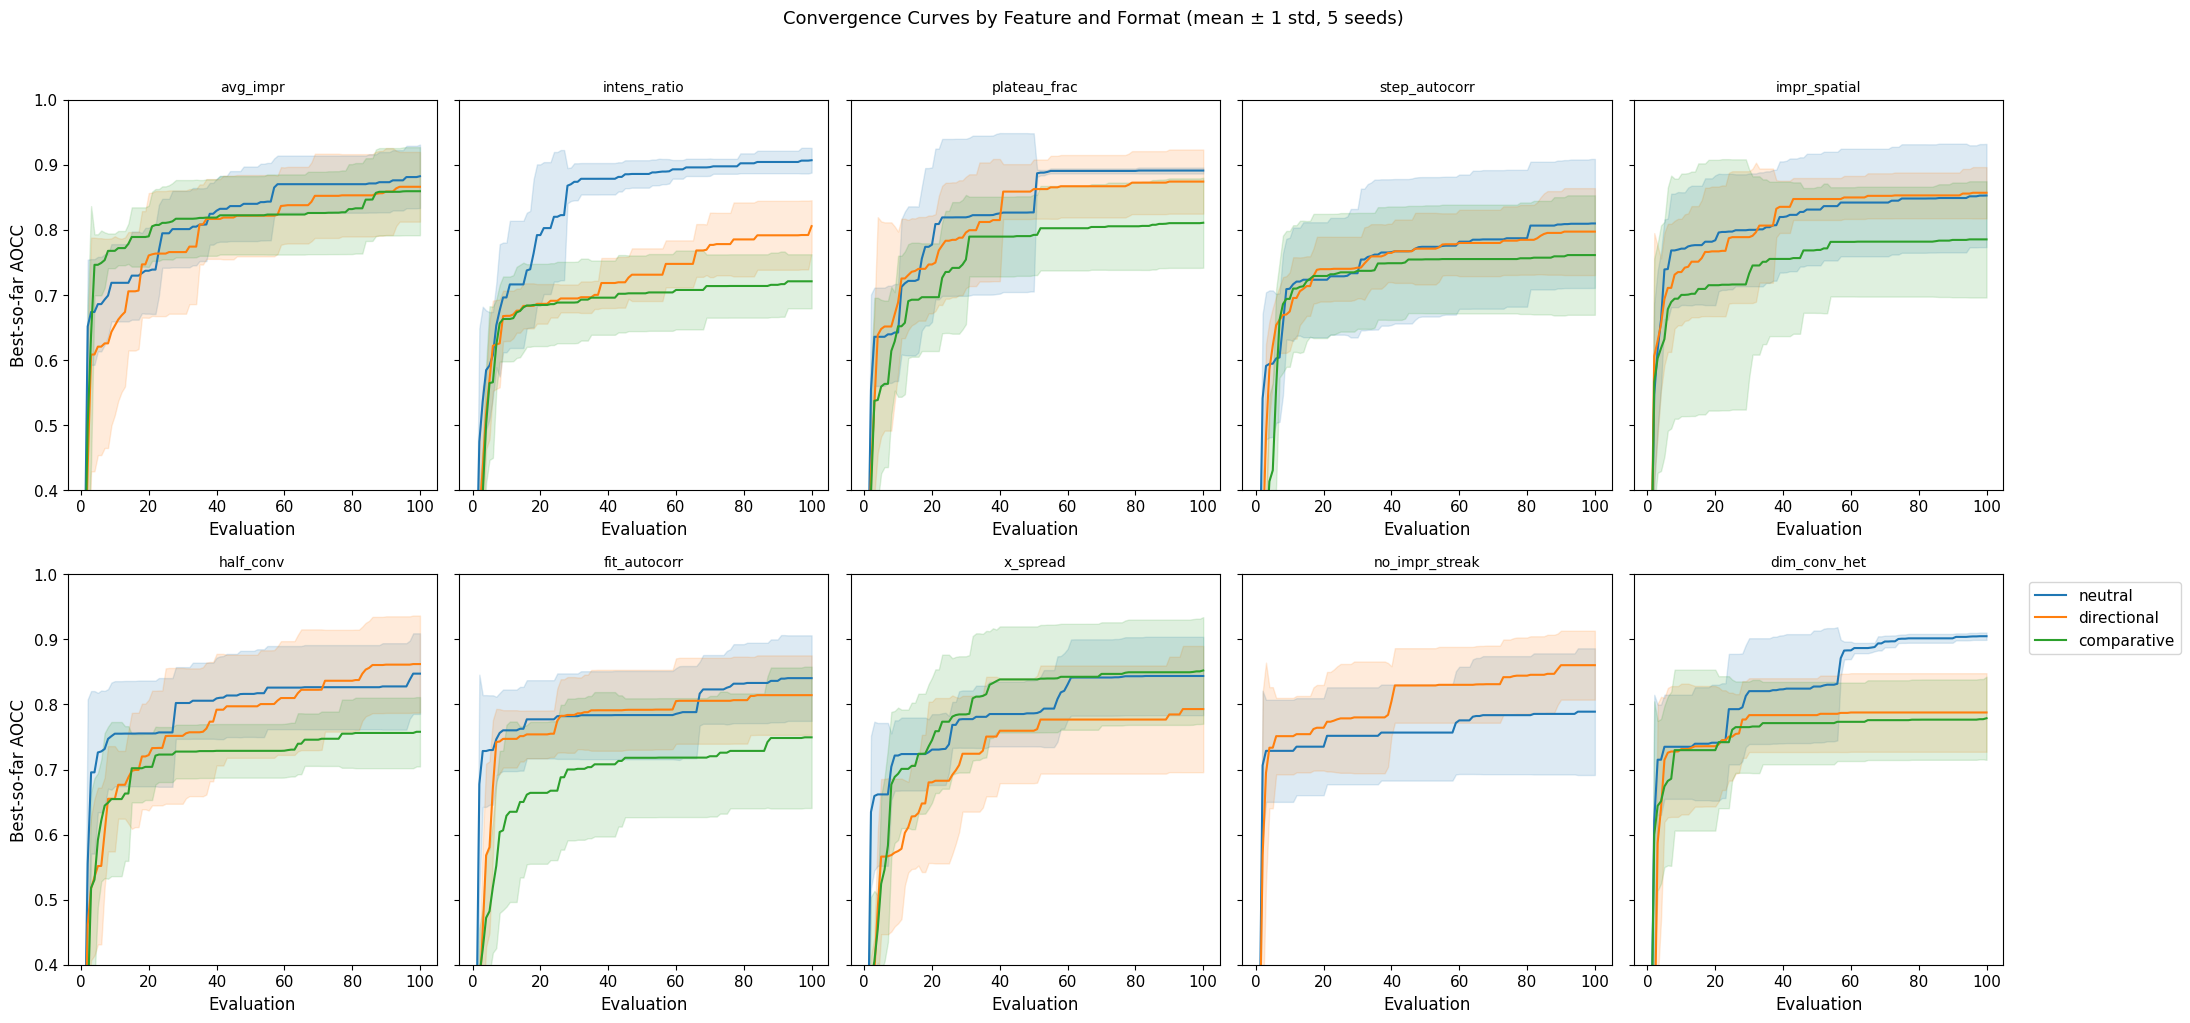

In [4]:
# Per-feature subplots with one curve per format — 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=True)
axes_flat = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    fmts = formats_for_feature(feat)
    for fmt in fmts:
        curves = []
        for seed in range(N_SEEDS):
            sub = df[(df["feature"] == feat) & (df["format"] == fmt) & (df["seed"] == seed)]
            sub = sub.sort_values("evaluation")
            if sub.empty:
                continue
            vals = sub["fitness"].values.copy()
            bsf = pd.Series(vals).expanding().max().values
            curves.append(bsf)

        if not curves:
            continue
        max_len = max(len(c) for c in curves)
        padded = [np.concatenate([c, np.full(max_len - len(c), c[-1])]) for c in curves]
        arr = np.array(padded)
        mean_c = np.nanmean(arr, axis=0)
        std_c = np.nanstd(arr, axis=0)
        x = np.arange(1, len(mean_c) + 1)
        ax.plot(x, mean_c, label=fmt, color=FORMAT_COLORS[fmt], linewidth=1.5)
        ax.fill_between(x, mean_c - std_c, mean_c + std_c, alpha=0.15, color=FORMAT_COLORS[fmt])

    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    ax.set_xlabel("Evaluation")
    if idx % 5 == 0:
        ax.set_ylabel("Best-so-far AOCC")
    ax.set_ylim(0.4, 1.0)

axes_flat[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.suptitle("Convergence Curves by Feature and Format (mean ± 1 std, 5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Failure Rate Comparison

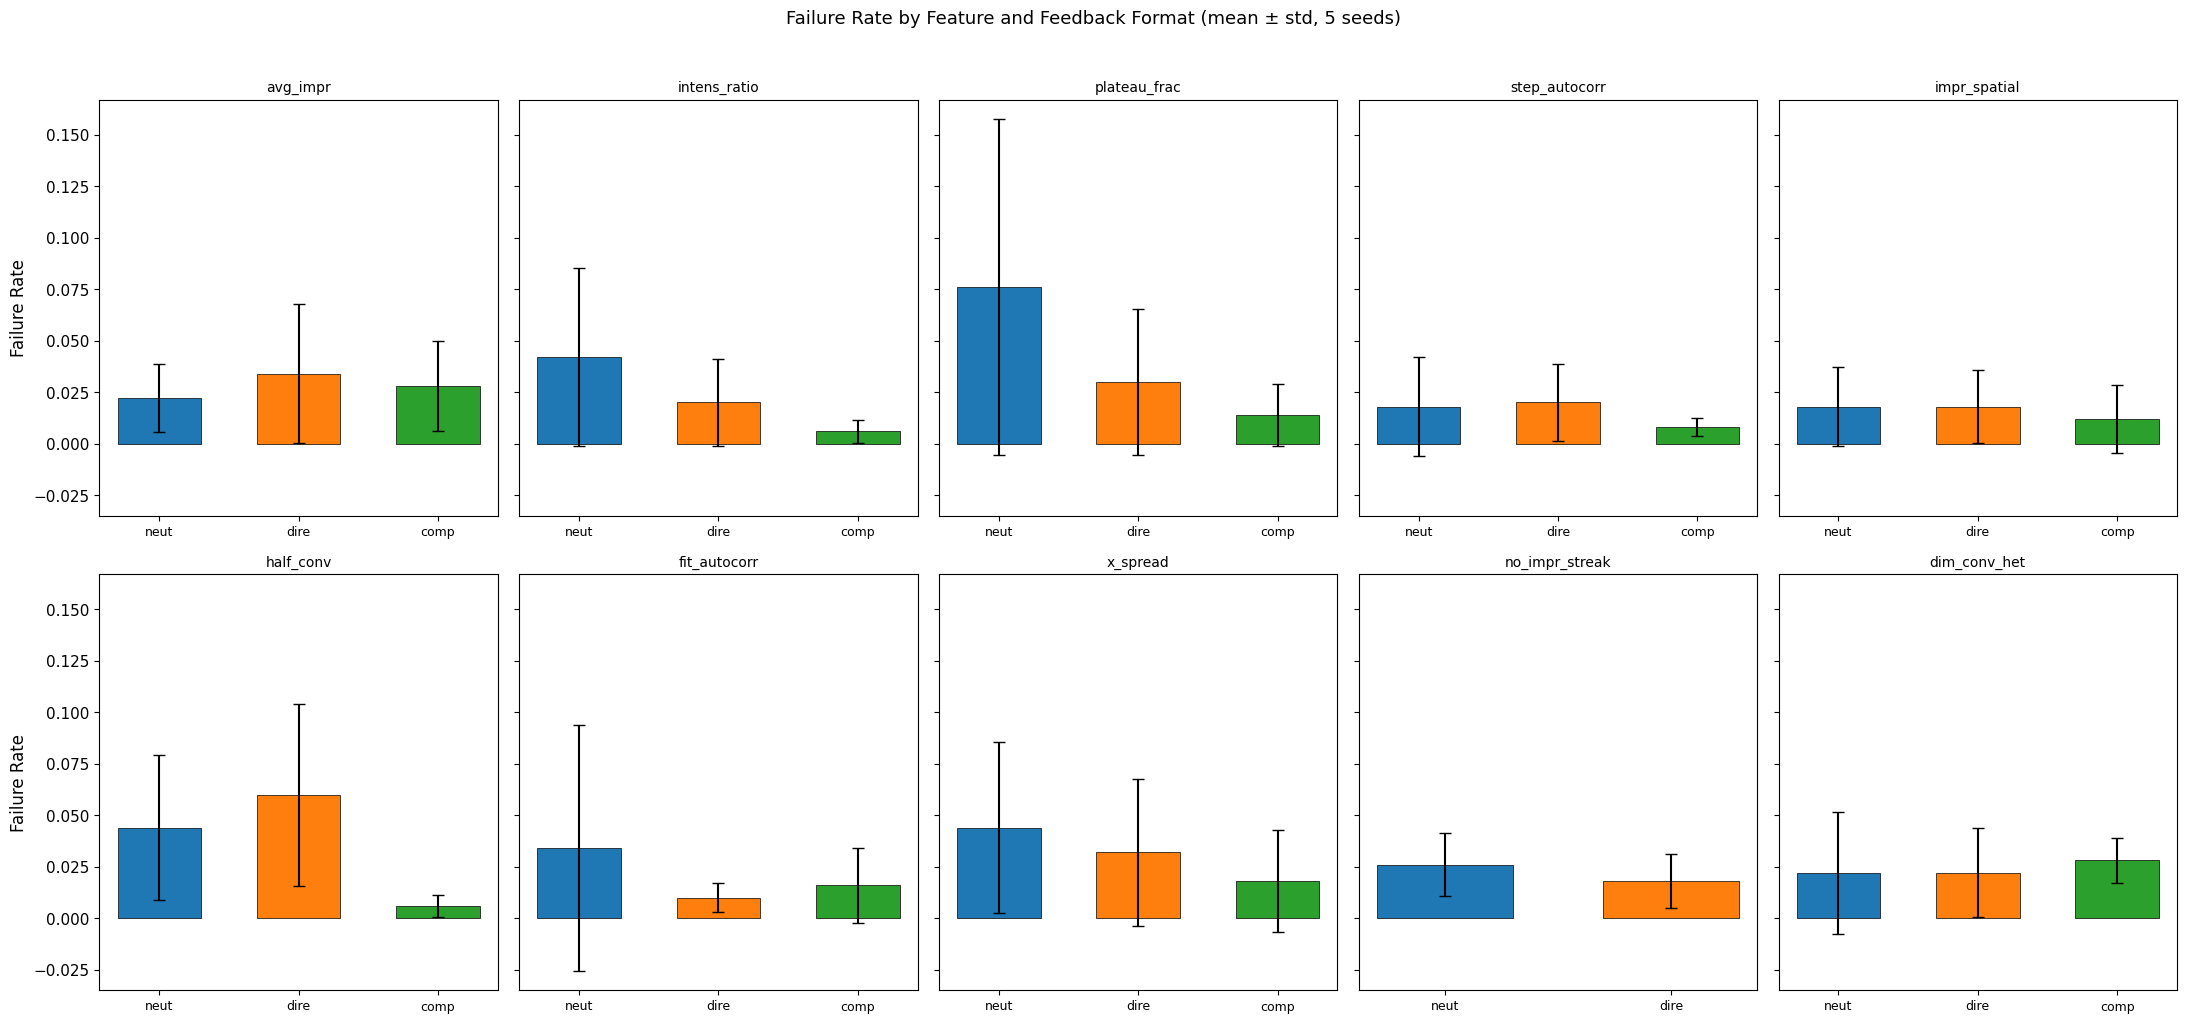

Failure rate by format (aggregated across all features):
               mean     std
format                     
comparative  0.0151  0.0160
directional  0.0264  0.0280
neutral      0.0346  0.0414


In [5]:
# Failure rate per (condition, seed), then summarize
fail_per_seed = df.groupby(["condition", "format", "feature", "seed"])["failed"].mean().reset_index()
fail_per_seed.columns = ["condition", "format", "feature", "seed", "failure_rate"]

fail_summary = fail_per_seed.groupby(["feature", "format"])["failure_rate"].agg(["mean", "std"]).reset_index()
fail_summary.columns = ["feature", "format", "fail_mean", "fail_std"]

# 2x5 grouped bar chart
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=True)
axes_flat = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    fmts = formats_for_feature(feat)
    sub = fail_summary[fail_summary["feature"] == feat].set_index("format")
    x = np.arange(len(fmts))
    vals = [sub.loc[f, "fail_mean"] if f in sub.index else 0 for f in fmts]
    errs = [sub.loc[f, "fail_std"] if f in sub.index else 0 for f in fmts]
    ax.bar(x, vals, yerr=errs, color=[FORMAT_COLORS[f] for f in fmts],
           edgecolor="black", linewidth=0.5, capsize=4, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:4] for f in fmts], fontsize=9)
    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    if idx % 5 == 0:
        ax.set_ylabel("Failure Rate")

fig.suptitle("Failure Rate by Feature and Feedback Format (mean ± std, 5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Failure rate by format (aggregated across all features):")
print(fail_per_seed.groupby("format")["failure_rate"].agg(["mean", "std"]).round(4).to_string())

## 5. Per-Instance AOCC Heatmap (best algorithm per condition)

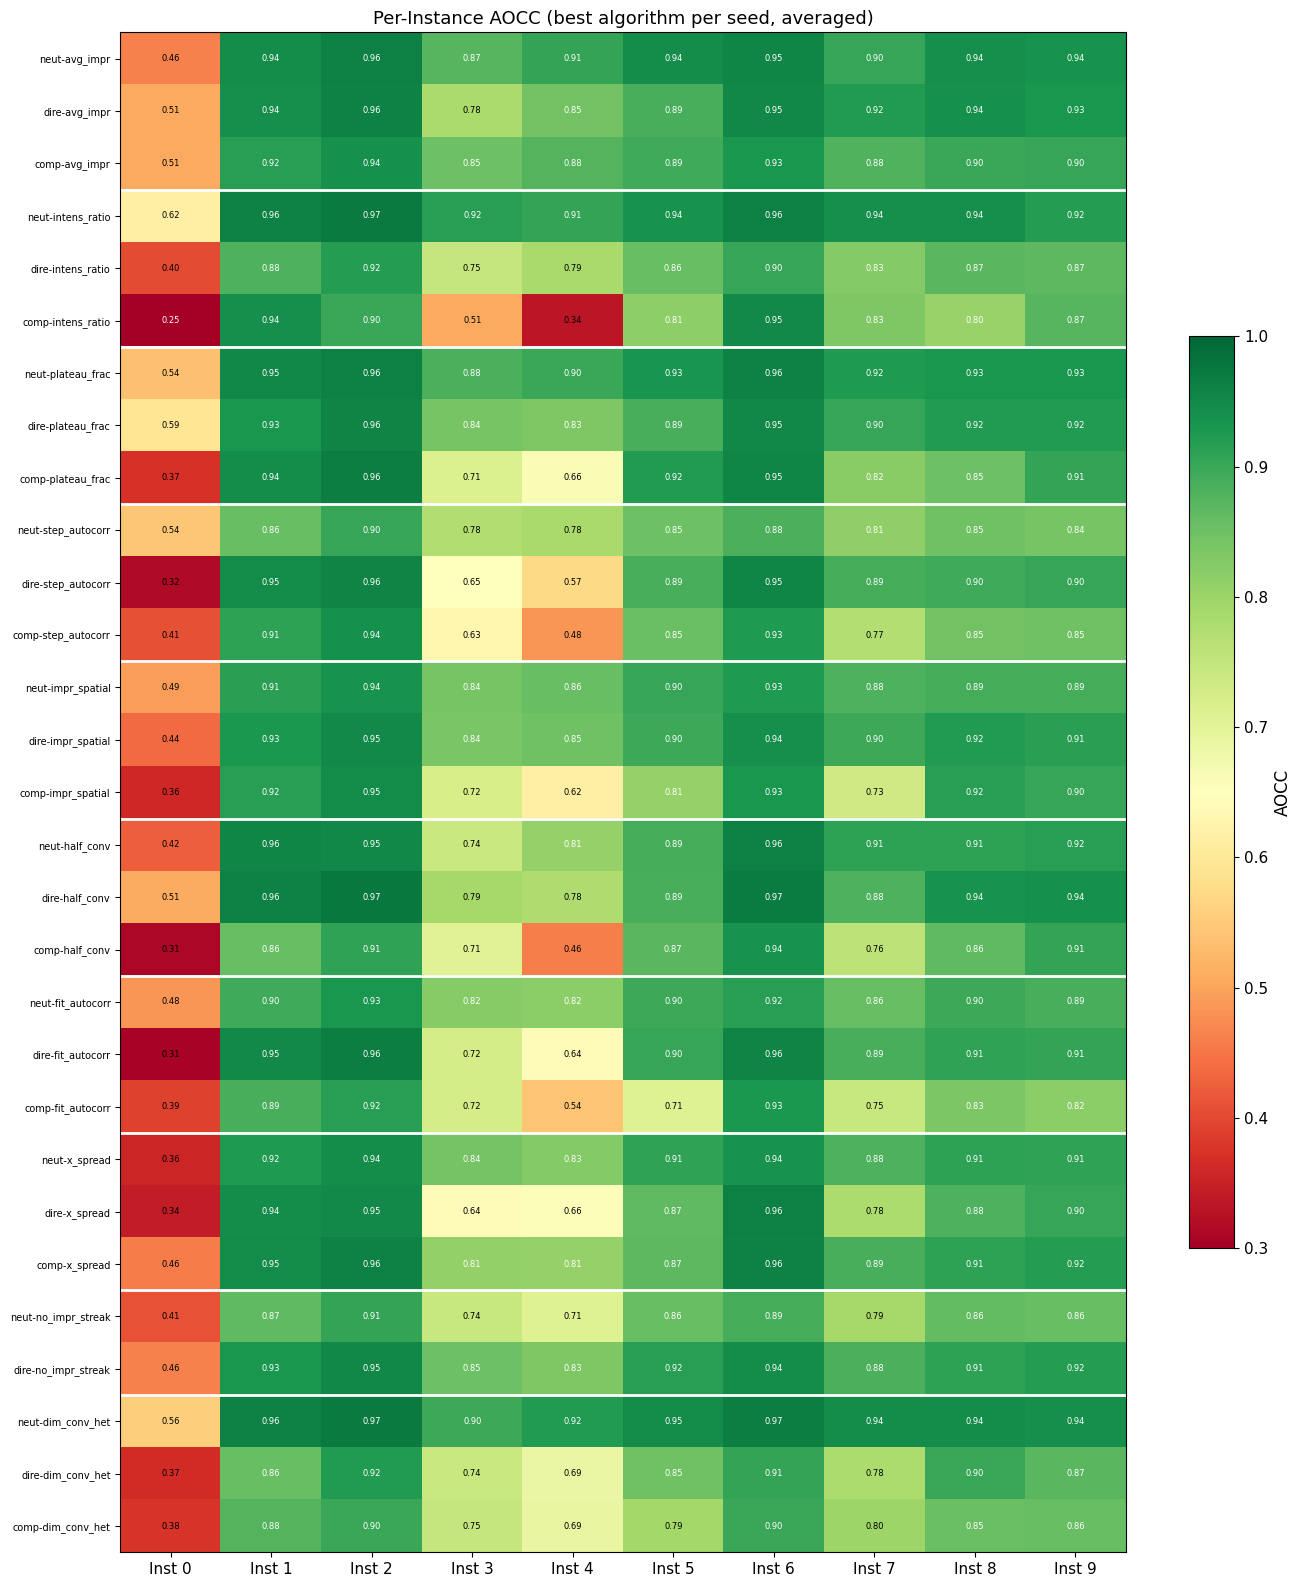

In [6]:
# For each condition, find best algorithm per seed, get per-instance AUCs, average over seeds
cond_labels = []
instance_matrix = []

for feat in FEATURES:
    fmts = formats_for_feature(feat)
    for fmt in fmts:
        cond = f"{fmt}-{feat}"
        seed_instances = []
        for seed in range(N_SEEDS):
            sub = df[(df["condition"] == cond) & (df["seed"] == seed)]
            if sub.empty:
                continue
            best_idx = sub["fitness"].idxmax()
            aucs = sub.loc[best_idx, "aucs"]
            if not aucs or len(aucs) != N_INSTANCES * EVAL_SEEDS:
                continue
            aucs_arr = np.array(aucs).reshape(N_INSTANCES, EVAL_SEEDS)
            seed_instances.append(aucs_arr.mean(axis=1))

        if seed_instances:
            stacked = np.array(seed_instances)
            instance_matrix.append(stacked.mean(axis=0))
        else:
            instance_matrix.append(np.full(N_INSTANCES, np.nan))
        cond_labels.append(f"{fmt[:4]}-{FEATURE_SHORT[feat]}")

instance_matrix = np.array(instance_matrix)

fig, ax = plt.subplots(figsize=(14, 16))
im = ax.imshow(instance_matrix, aspect="auto", cmap="RdYlGn", vmin=0.3, vmax=1.0)

for i in range(instance_matrix.shape[0]):
    for j in range(instance_matrix.shape[1]):
        val = instance_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6,
                    color="black" if 0.3 < val < 0.8 else "white")

ax.set_xticks(range(N_INSTANCES))
ax.set_xticklabels([f"Inst {i}" for i in range(N_INSTANCES)])
ax.set_yticks(range(len(cond_labels)))
ax.set_yticklabels(cond_labels, fontsize=7)
ax.set_title("Per-Instance AOCC (best algorithm per seed, averaged)")

# Draw horizontal lines between features
row_idx = 0
for feat in FEATURES:
    n_fmts = len(formats_for_feature(feat))
    row_idx += n_fmts
    if row_idx < len(cond_labels):
        ax.axhline(y=row_idx - 0.5, color="white", linewidth=2)

plt.colorbar(im, ax=ax, label="AOCC", shrink=0.6)
plt.tight_layout()
plt.show()

## 6. Format-Level Aggregate Analysis

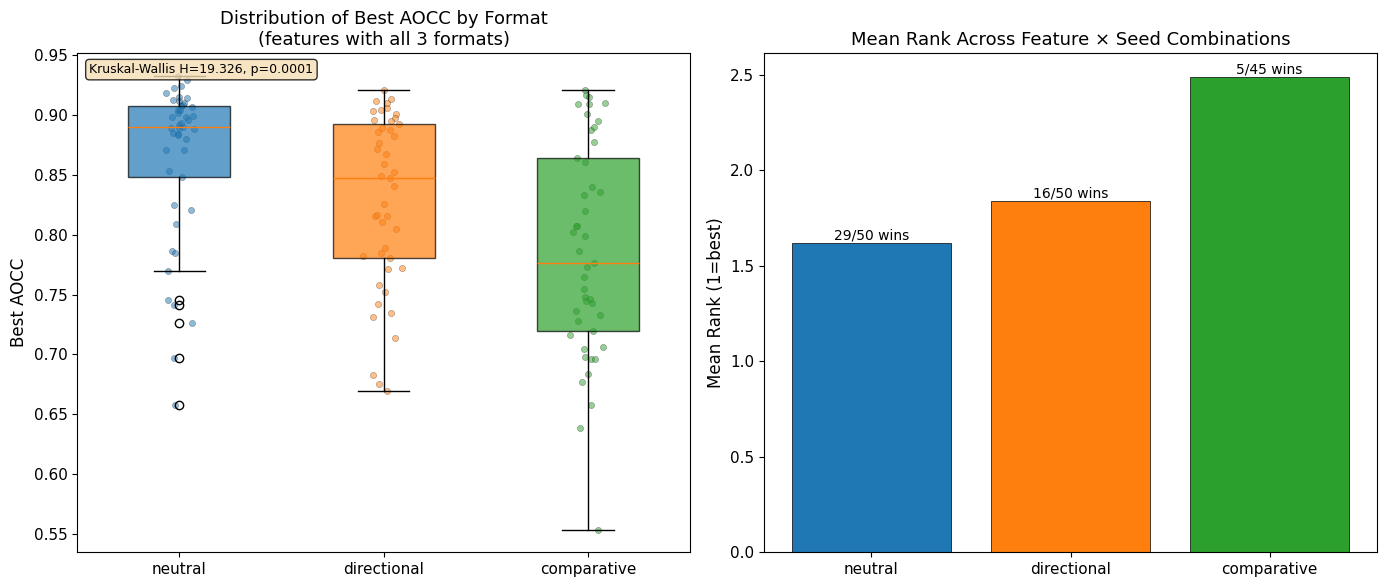


Mean rank per format:
format
comparative    2.489
directional    1.840
neutral        1.620

Win counts (rank 1): {'comparative': 5, 'directional': 16, 'neutral': 29}

Neutral vs Directional head-to-head (all 10 features, 50 matchups):
  Neutral wins: 29, Directional wins: 16


In [7]:
# Aggregate across all features: does format matter overall?

# Box plot of best AOCC per seed, grouped by format
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot — only use conditions where all 3 formats exist (exclude longest_no_improvement_streak)
best_3fmt = best[~best["feature"].isin(COMPARATIVE_EXCLUDE)]
format_data = [best_3fmt[best_3fmt["format"] == fmt]["best_aocc"].dropna().values for fmt in FORMATS]
bp = ax1.boxplot(format_data, labels=FORMATS, patch_artist=True, widths=0.5)
for patch, fmt in zip(bp["boxes"], FORMATS):
    patch.set_facecolor(FORMAT_COLORS[fmt])
    patch.set_alpha(0.7)
ax1.set_ylabel("Best AOCC")
ax1.set_title("Distribution of Best AOCC by Format\n(features with all 3 formats)")

# Strip plot overlay
for i, fmt in enumerate(FORMATS):
    vals = best_3fmt[best_3fmt["format"] == fmt]["best_aocc"].dropna().values
    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax1.scatter(np.full_like(vals, i + 1) + jitter, vals,
                alpha=0.5, s=20, color=FORMAT_COLORS[fmt], edgecolor="black", linewidth=0.3)

# Format-level Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*format_data)
ax1.text(0.02, 0.98, f"Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.4f}",
         transform=ax1.transAxes, va="top", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Ranking: for each (feature, seed), rank the formats
rank_rows = []
for feat in FEATURES:
    fmts = formats_for_feature(feat)
    for seed in range(N_SEEDS):
        seed_vals = {}
        for fmt in fmts:
            sub = best[(best["feature"] == feat) & (best["format"] == fmt) & (best["seed"] == seed)]
            if not sub.empty:
                seed_vals[fmt] = sub["best_aocc"].values[0]
        if len(seed_vals) == len(fmts):
            ranked = sorted(seed_vals.items(), key=lambda x: -x[1])
            for rank, (fmt, val) in enumerate(ranked):
                rank_rows.append({"feature": feat, "seed": seed, "format": fmt, "rank": rank + 1})

rank_df = pd.DataFrame(rank_rows)

# For ranking comparison, use only neutral vs directional (available for all 10 features)
nd_rank = rank_df[rank_df["format"].isin(["neutral", "directional"])]
for feat in FEATURES:
    fmts = formats_for_feature(feat)
    for seed in range(N_SEEDS):
        sub = nd_rank[(nd_rank["feature"] == feat) & (nd_rank["seed"] == seed)]

mean_rank = rank_df.groupby("format")["rank"].mean()
win_counts = rank_df[rank_df["rank"] == 1].groupby("format").size()

ax2.bar(FORMATS, [mean_rank.get(f, 0) for f in FORMATS],
        color=[FORMAT_COLORS[f] for f in FORMATS], edgecolor="black", linewidth=0.5)
ax2.set_ylabel("Mean Rank (1=best)")
ax2.set_title("Mean Rank Across Feature × Seed Combinations")
for i, fmt in enumerate(FORMATS):
    wins = win_counts.get(fmt, 0)
    total = len(rank_df[rank_df["format"] == fmt])
    ax2.text(i, mean_rank.get(fmt, 0) + 0.02, f"{wins}/{total} wins", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\nMean rank per format:")
print(mean_rank.round(3).to_string())
print(f"\nWin counts (rank 1): {win_counts.to_dict()}")

# Neutral vs directional head-to-head (all 10 features)
nd_only = rank_df[rank_df["format"].isin(["neutral", "directional"])]
n_wins = len(nd_only[(nd_only["format"] == "neutral") & (nd_only["rank"] == 1)])
d_wins = len(nd_only[(nd_only["format"] == "directional") & (nd_only["rank"] == 1)])
print(f"\nNeutral vs Directional head-to-head (all 10 features, 50 matchups):")
print(f"  Neutral wins: {n_wins}, Directional wins: {d_wins}")

## 7. Overall Condition Ranking

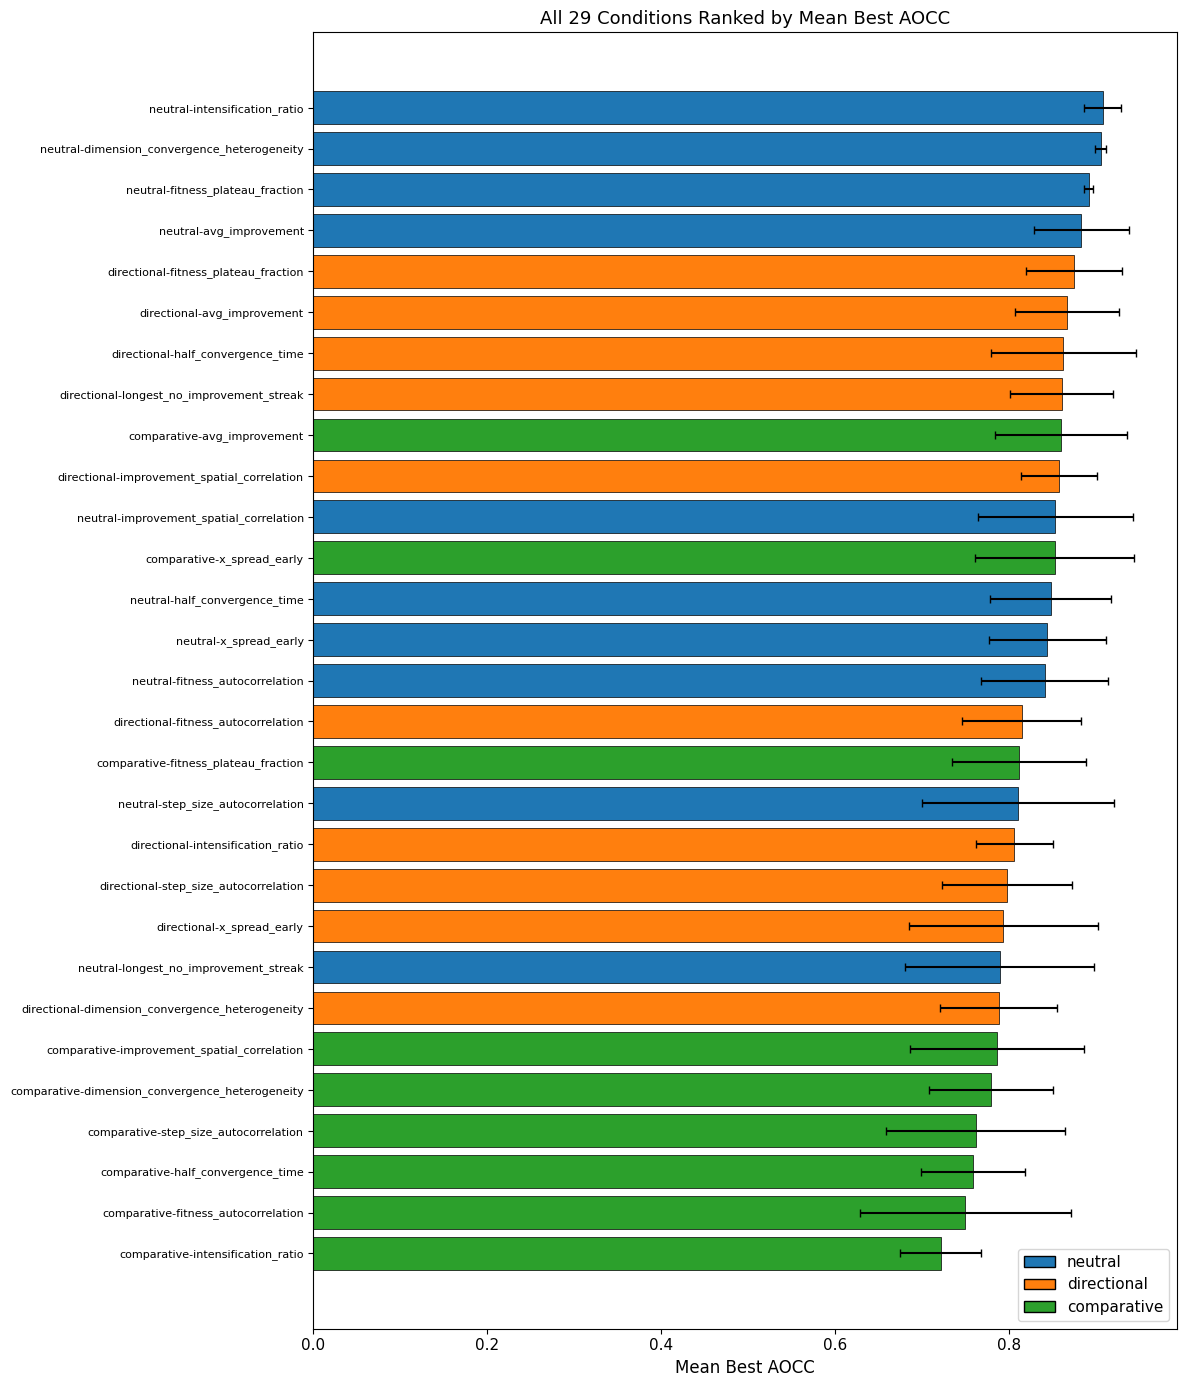

Full Ranking:
Rank                                           Condition  AOCC Mean  AOCC Std   Fail%
   1                       neutral-intensification_ratio     0.9072    0.0212    4.2%
   2         neutral-dimension_convergence_heterogeneity     0.9049    0.0063    2.2%
   3                    neutral-fitness_plateau_fraction     0.8913    0.0052    7.6%
   4                             neutral-avg_improvement     0.8826    0.0545    2.2%
   5                directional-fitness_plateau_fraction     0.8743    0.0551    3.0%
   6                         directional-avg_improvement     0.8664    0.0599    3.4%
   7                   directional-half_convergence_time     0.8621    0.0834    6.0%
   8           directional-longest_no_improvement_streak     0.8604    0.0592    1.8%
   9                         comparative-avg_improvement     0.8595    0.0757    2.8%
  10         directional-improvement_spatial_correlation     0.8572    0.0441    1.8%
  11             neutral-improvement_spa

In [8]:
# Rank all 29 conditions by mean best AOCC
cond_summary = best.groupby(["condition", "format", "feature"])["best_aocc"].agg(["mean", "std"]).reset_index()
cond_summary.columns = ["condition", "format", "feature", "aocc_mean", "aocc_std"]

# Add failure rate
fail_agg = fail_per_seed.groupby("condition")["failure_rate"].mean().reset_index()
fail_agg.columns = ["condition", "fail_rate"]
cond_summary = cond_summary.merge(fail_agg, on="condition")
cond_summary = cond_summary.sort_values("aocc_mean", ascending=False).reset_index(drop=True)

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 14))
y_pos = np.arange(len(cond_summary))
colors = [FORMAT_COLORS[row["format"]] for _, row in cond_summary.iterrows()]

ax.barh(y_pos, cond_summary["aocc_mean"], xerr=cond_summary["aocc_std"],
        color=colors, edgecolor="black", linewidth=0.5, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(cond_summary["condition"], fontsize=8)
ax.set_xlabel("Mean Best AOCC")
ax.set_title("All 29 Conditions Ranked by Mean Best AOCC")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=FORMAT_COLORS[f], edgecolor="black", label=f) for f in FORMATS]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

# Table
print("Full Ranking:")
print(f"{'Rank':>4s}  {'Condition':>50s}  {'AOCC Mean':>9s}  {'AOCC Std':>8s}  {'Fail%':>6s}")
for i, row in cond_summary.iterrows():
    print(f"{i+1:4d}  {row['condition']:>50s}  {row['aocc_mean']:9.4f}  {row['aocc_std']:8.4f}  {row['fail_rate']:6.1%}")

## 8. Comparison with Phase 1 Vanilla Baseline

Phase 1 vanilla baseline (gemini-3-flash): 0.8615 +/- 0.0968
  Per-seed: ['0.6696', '0.8872', '0.9076', '0.9227', '0.9205']

                                         Condition       AOCC   vs Van    p-val      Effect
------------------------------------------------------------------------------------------
                     neutral-intensification_ratio     0.9072   +0.046   0.6905  +0.200 (small)
       neutral-dimension_convergence_heterogeneity     0.9049   +0.043   1.0000  -0.040 (negligible)
                  neutral-fitness_plateau_fraction     0.8913   +0.030   0.5476  -0.280 (small)
                           neutral-avg_improvement     0.8826   +0.021   1.0000  -0.040 (negligible)
              directional-fitness_plateau_fraction     0.8743   +0.013   0.6905  -0.200 (small)
                       directional-avg_improvement     0.8664   +0.005   0.5476  -0.280 (small)
                 directional-half_convergence_time     0.8621   +0.001   0.6905  -0.200 (small)
         d

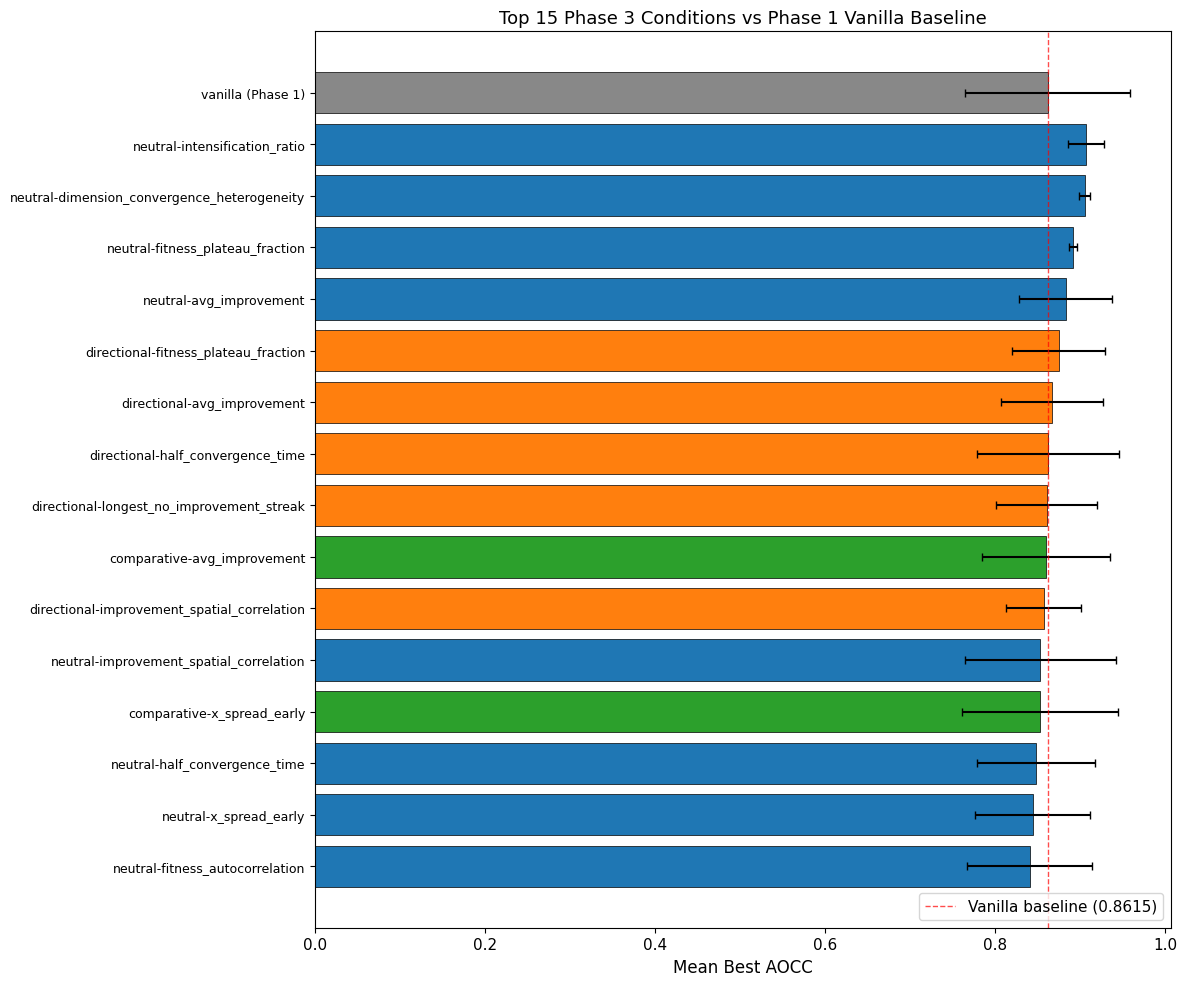

In [9]:
# Load Phase 1 gemini-3-flash results as vanilla baseline
PHASE1_DIR = Path("../results_phase1")

vanilla_best = []
for seed in range(N_SEEDS):
    seed_dir = PHASE1_DIR / "gemini-3-flash" / f"seed-{seed}"
    run_dirs = sorted(seed_dir.glob("run-*"))
    if not run_dirs:
        continue
    log_file = run_dirs[0] / "log.jsonl"
    if not log_file.exists():
        continue
    best_fitness = -np.inf
    with open(log_file) as f:
        for line in f:
            entry = json.loads(line.strip())
            fit = parse_fitness(entry.get("fitness"))
            if fit is not None and not np.isnan(fit) and fit > best_fitness:
                best_fitness = fit
    if best_fitness > -np.inf:
        vanilla_best.append(best_fitness)

vanilla_mean = np.mean(vanilla_best)
vanilla_std = np.std(vanilla_best)
print(f"Phase 1 vanilla baseline (gemini-3-flash): {vanilla_mean:.4f} +/- {vanilla_std:.4f}")
print(f"  Per-seed: {[f'{v:.4f}' for v in vanilla_best]}")

# Compare each condition against vanilla
print(f"\n{'Condition':>50s}  {'AOCC':>9s}  {'vs Van':>7s}  {'p-val':>7s}  {'Effect':>10s}")
print("-" * 90)
for _, row in cond_summary.iterrows():
    cond_vals = best[best["condition"] == row["condition"]]["best_aocc"].dropna().values
    if len(cond_vals) >= 2 and len(vanilla_best) >= 2:
        _, p = stats.mannwhitneyu(cond_vals, vanilla_best, alternative="two-sided")
        d = cliffs_delta(cond_vals, vanilla_best)
        diff = row["aocc_mean"] - vanilla_mean
        sig = "*" if p < 0.05 else ""
        print(f"{row['condition']:>50s}  {row['aocc_mean']:9.4f}  "
              f"{diff:+7.3f}  {p:7.4f}{sig}  {d:+.3f} ({cliffs_label(d)})")

# Visual comparison — show top 15 + vanilla
top15 = cond_summary.head(15)
fig, ax = plt.subplots(figsize=(12, 10))
y_pos = np.arange(len(top15) + 1)
labels = ["vanilla (Phase 1)"] + top15["condition"].tolist()
means = [vanilla_mean] + top15["aocc_mean"].tolist()
stds = [vanilla_std] + top15["aocc_std"].tolist()
colors = ["#888888"] + [FORMAT_COLORS[row["format"]] for _, row in top15.iterrows()]

ax.barh(y_pos, means, xerr=stds, color=colors, edgecolor="black", linewidth=0.5, capsize=3)
ax.axvline(x=vanilla_mean, color="red", linestyle="--", linewidth=1, alpha=0.7,
           label=f"Vanilla baseline ({vanilla_mean:.4f})")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Mean Best AOCC")
ax.set_title("Top 15 Phase 3 Conditions vs Phase 1 Vanilla Baseline")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Behavioral Steering: Did feedback change the guided feature?
For each condition, compare the guided feature's value across formats.
Baseline: neutral condition (minimal intervention).

Loaded 14127 valid evaluations with behavioral features


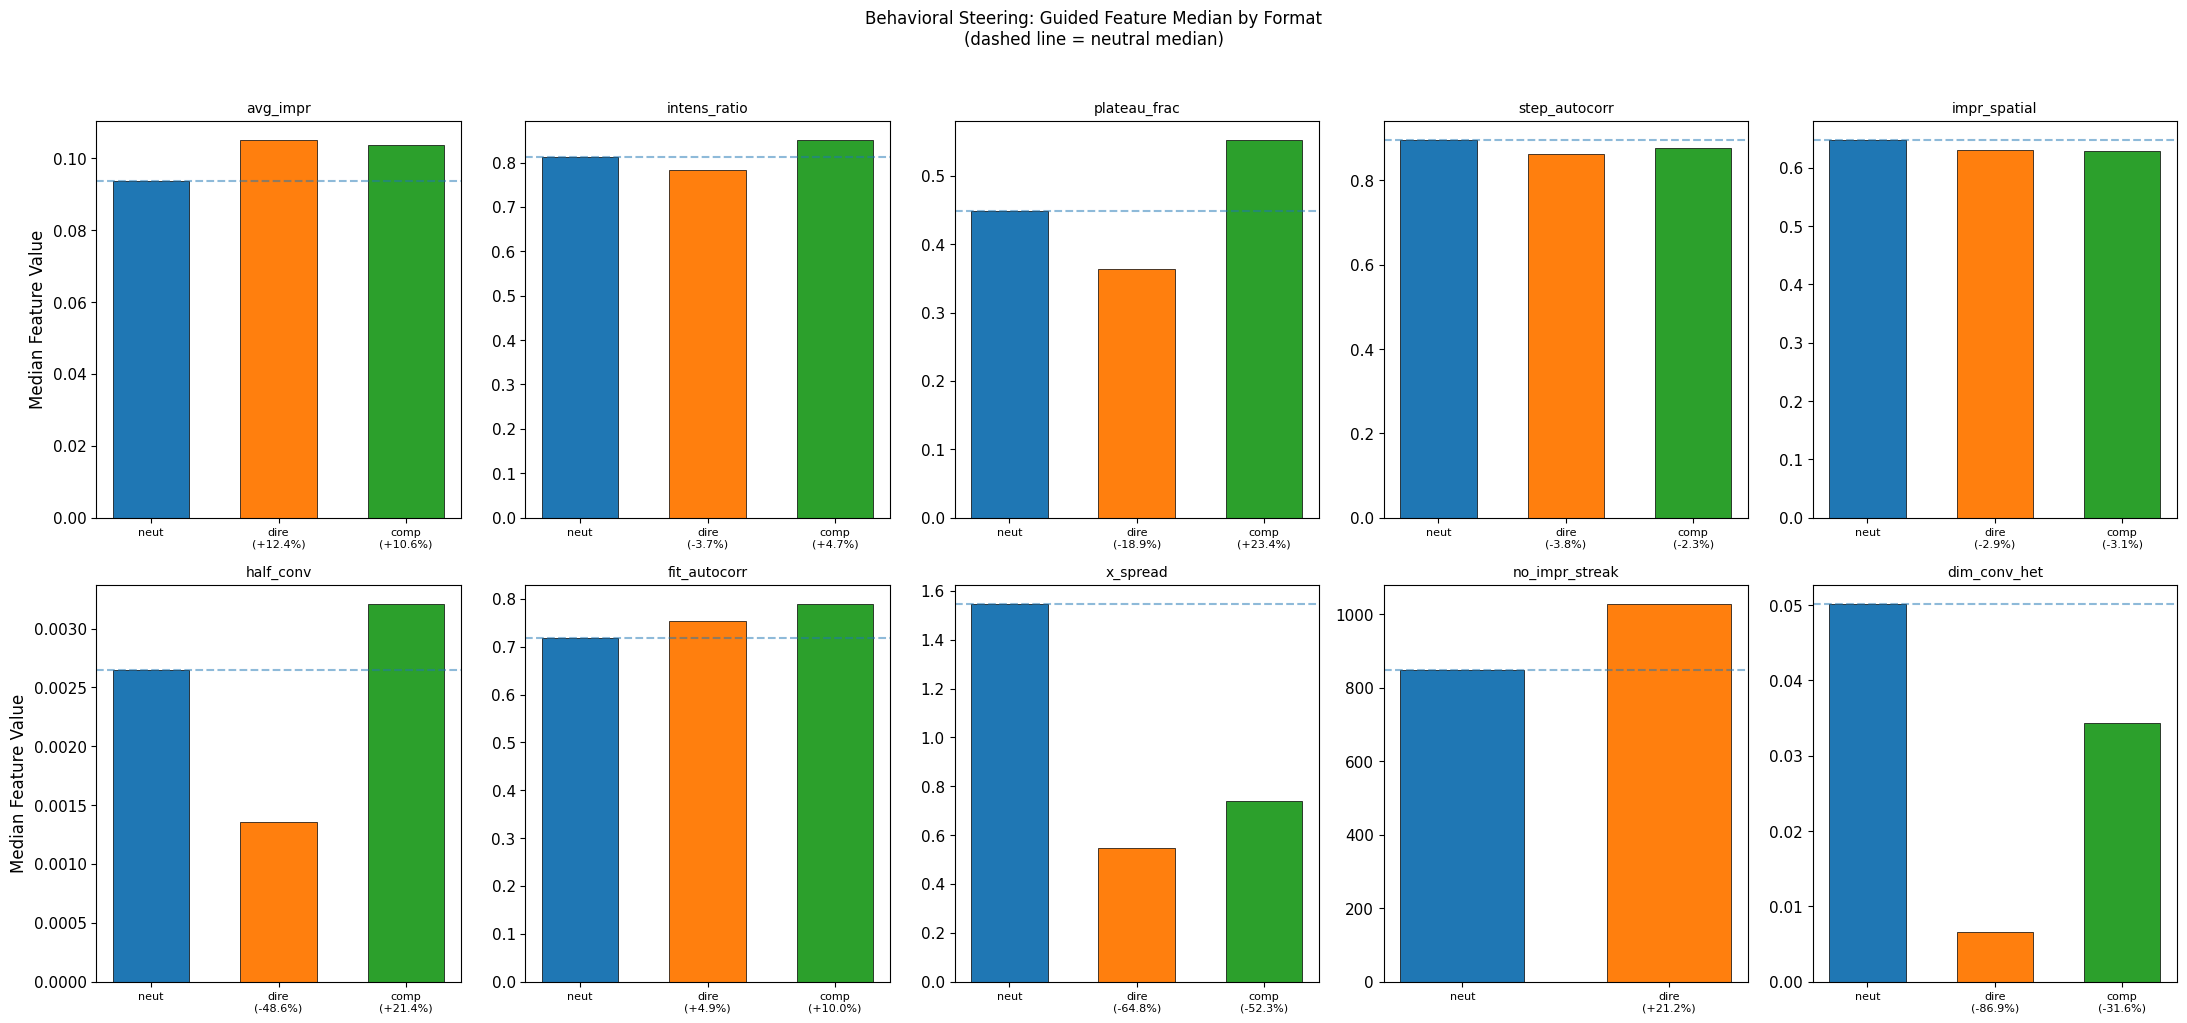


Directional/Comparative vs Neutral (guided feature shift):
                                      Feature        Format    Median  vs Neutral     p-val
------------------------------------------------------------------------------------------
                              avg_improvement   directional    0.1053     +0.0116    0.0327*
                              avg_improvement   comparative    0.1036     +0.0099    0.0010*
                        intensification_ratio   directional    0.7831     -0.0304    0.0161*
                        intensification_ratio   comparative    0.8518     +0.0384    0.0000*
                     fitness_plateau_fraction   directional    0.3636     -0.0846    0.0041*
                     fitness_plateau_fraction   comparative    0.5532     +0.1050    0.0000*
                    step_size_autocorrelation   directional    0.8630     -0.0342    0.0000*
                    step_size_autocorrelation   comparative    0.8769     -0.0203    0.0000*
             

In [10]:
# Load behavioral feature values for ALL conditions
bf_rows = []
for cond in CONDITIONS:
    parts = cond.split("-", 1)
    fmt, feat = parts[0], parts[1]
    for seed in range(N_SEEDS):
        seed_dir = RESULTS_DIR / cond / f"seed-{seed}"
        run_dirs = sorted(seed_dir.glob("run-*"))
        if not run_dirs:
            continue
        log_file = run_dirs[0] / "log.jsonl"
        if not log_file.exists():
            continue
        with open(log_file) as f:
            for i, line in enumerate(f):
                entry = json.loads(line.strip())
                fitness = parse_fitness(entry.get("fitness"))
                if np.isnan(fitness):
                    continue
                bf = entry.get("metadata", {}).get("behavioral_features", {})
                if not bf:
                    continue
                row = {
                    "condition": cond, "format": fmt, "feature": feat,
                    "seed": seed, "evaluation": i, "fitness": fitness,
                }
                for bk, bv in bf.items():
                    row[f"bf_{bk}"] = bv
                bf_rows.append(row)

bf_df = pd.DataFrame(bf_rows)
print(f"Loaded {len(bf_df)} valid evaluations with behavioral features")

# --- 2x5 grid: median guided feature per format ---
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=False)
axes_flat = axes.flatten()

steering_summary = []

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        ax.set_visible(False)
        continue

    fmts = formats_for_feature(feat)
    medians = []
    fmt_labels = []
    colors = []

    neutral_vals = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == "neutral")][col].dropna()
    neutral_median = neutral_vals.median()

    for fmt in fmts:
        guided = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt)][col].dropna()
        if len(guided) == 0:
            continue
        diff_pct = (guided.median() - neutral_median) / abs(neutral_median) * 100 if neutral_median != 0 else 0
        medians.append(guided.median())
        label = f"{fmt[:4]}"
        if fmt != "neutral":
            label += f"\n({diff_pct:+.1f}%)"
        fmt_labels.append(label)
        colors.append(FORMAT_COLORS[fmt])

        if fmt != "neutral":
            _, p = stats.mannwhitneyu(guided, neutral_vals, alternative="two-sided")
            steering_summary.append({
                "feature": feat, "format": fmt,
                "guided_median": guided.median(), "neutral_median": neutral_median,
                "diff_pct": diff_pct, "p": p, "sig": p < 0.05,
            })

    x_pos = np.arange(len(fmt_labels))
    ax.bar(x_pos, medians, color=colors, edgecolor="black", linewidth=0.5, width=0.6)
    ax.axhline(y=neutral_median, color="#1f77b4", linestyle="--", linewidth=1.5, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(fmt_labels, fontsize=8)
    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    if idx % 5 == 0:
        ax.set_ylabel("Median Feature Value")

fig.suptitle("Behavioral Steering: Guided Feature Median by Format\n"
             "(dashed line = neutral median)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nDirectional/Comparative vs Neutral (guided feature shift):")
print(f"{'Feature':>45s}  {'Format':>12s}  {'Median':>8s}  {'vs Neutral':>10s}  {'p-val':>8s}")
print("-" * 90)
for s in steering_summary:
    sig = "*" if s["sig"] else ""
    diff = s["guided_median"] - s["neutral_median"]
    print(f"{s['feature']:>45s}  {s['format']:>12s}  {s['guided_median']:8.4f}  "
          f"{diff:+10.4f}  {s['p']:8.4f}{sig}")

## 10. Steering Direction Validation
Verify that the directional guidance was given correctly (matching feature-AOCC correlation),
then check whether the LLM actually pushed algorithms in the right direction.

FEATURE-AOCC CORRELATION (Spearman, across all valid algorithms)
                                      Feature      rho       p-val   Corr Dir      Advice   Match?
----------------------------------------------------------------------------------------------------
                              avg_improvement   -0.184   2.49e-107***      lower       lower      YES
                        intensification_ratio   +0.475    0.00e+00***     higher      higher      YES
                     fitness_plateau_fraction   +0.578    0.00e+00***     higher      higher      YES
                    step_size_autocorrelation   +0.468    0.00e+00***     higher      higher      YES
              improvement_spatial_correlation   +0.446    0.00e+00***     higher      higher      YES
                        half_convergence_time   -0.640    0.00e+00***      lower       lower      YES
                      fitness_autocorrelation   +0.138    1.36e-60***     higher      higher      YES
                     

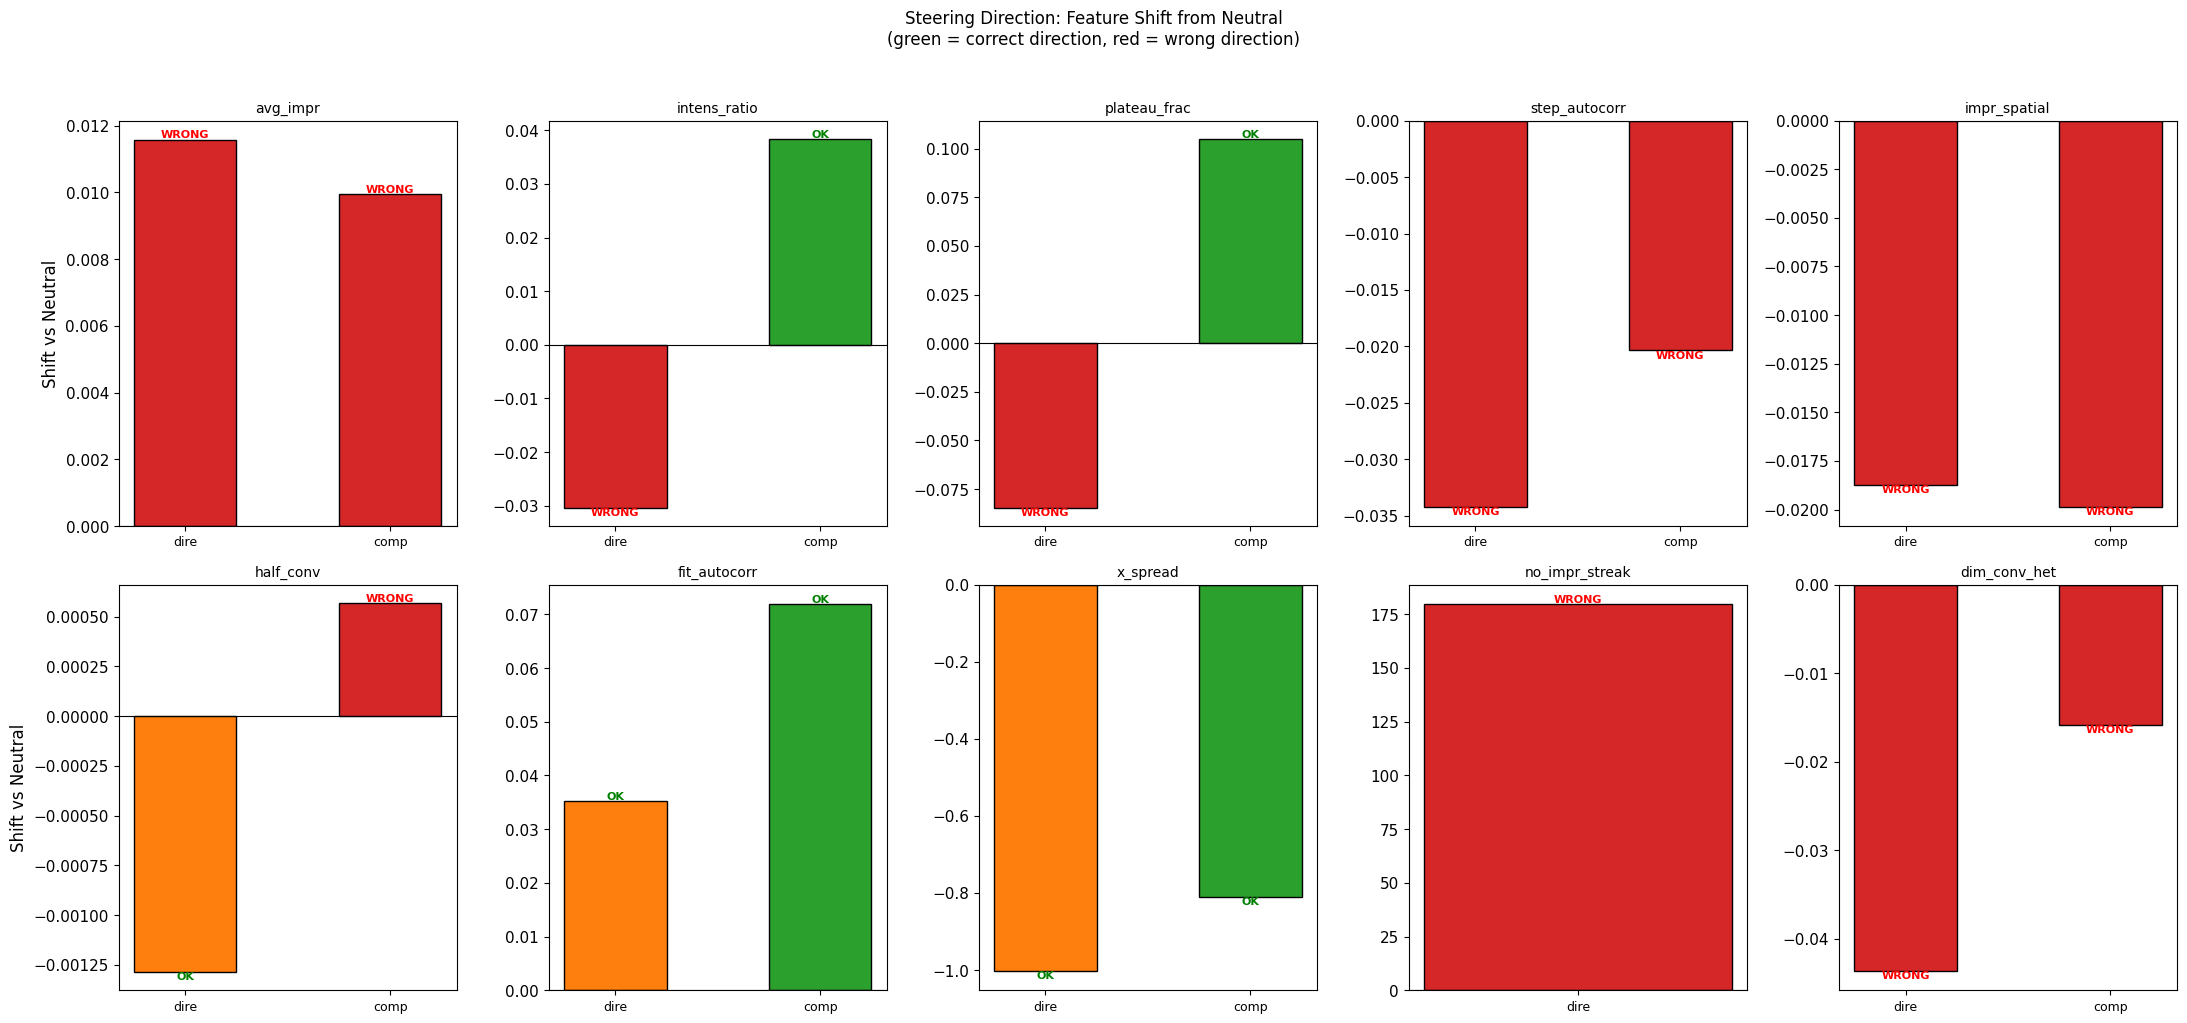

In [11]:
# 1. Feature-AOCC correlation (Spearman) across ALL valid algorithms
print("=" * 100)
print("FEATURE-AOCC CORRELATION (Spearman, across all valid algorithms)")
print("=" * 100)

from experiments.feedback import FEATURE_DIRECTIONS

correlations = {}

print(f"{'Feature':>45s}  {'rho':>7s}  {'p-val':>10s}  {'Corr Dir':>9s}  "
      f"{'Advice':>10s}  {'Match?':>7s}")
print("-" * 100)

for feat in FEATURES:
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        continue
    valid = bf_df[[col, "fitness"]].dropna()
    rho, p = stats.spearmanr(valid[col], valid["fitness"])
    corr_dir = "higher" if rho > 0 else "lower"
    advice_dir = FEATURE_DIRECTIONS[feat][0]
    match = "YES" if corr_dir == advice_dir else "NO"
    correlations[feat] = {"rho": rho, "corr_dir": corr_dir, "advice_dir": advice_dir}
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{feat:>45s}  {rho:+7.3f}  {p:10.2e}{sig:3s}  {corr_dir:>9s}  "
          f"{advice_dir:>10s}  {match:>7s}")

# 2. Steering direction check — 2x5 grid
print()
print("=" * 100)
print("STEERING CHECK: Did feedback push the feature toward better AOCC?")
print("=" * 100)

steering_results = []
for feat in FEATURES:
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        continue
    desired = correlations[feat]["advice_dir"]
    neutral_med = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == "neutral")][col].median()

    for fmt in formats_for_feature(feat):
        med = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt)][col].median()
        diff = med - neutral_med

        if fmt == "neutral":
            correct = "-"
        elif desired == "higher":
            correct = "YES" if diff > 0 else "NO"
        else:
            correct = "YES" if diff < 0 else "NO"

        steering_results.append({
            "feature": feat, "format": fmt, "median": med,
            "diff_vs_neutral": diff, "correct": correct, "desired": desired,
        })

steer_df = pd.DataFrame(steering_results)
steer_non_neutral = steer_df[steer_df["format"] != "neutral"]

print(f"{'Feature':>45s}  {'Advice':>7s}  {'Format':>12s}  {'Median':>10s}  "
      f"{'vs Neutral':>10s}  {'Right?':>7s}")
print("-" * 100)
for _, r in steer_df.iterrows():
    print(f"{r['feature']:>45s}  {r['desired']:>7s}  {r['format']:>12s}  {r['median']:10.4f}  "
          f"{r['diff_vs_neutral']:+10.4f}  {r['correct']:>7s}")

n_correct = (steer_non_neutral["correct"] == "YES").sum()
n_total = len(steer_non_neutral)
print(f"\nOverall steering accuracy: {n_correct}/{n_total} format-feature pairs pushed in the correct direction")

for fmt in ["directional", "comparative"]:
    sub = steer_non_neutral[steer_non_neutral["format"] == fmt]
    nc = (sub["correct"] == "YES").sum()
    nt = len(sub)
    print(f"  {fmt}: {nc}/{nt} correct")

# Plot: 2x5 grid of deviation from neutral
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=False)
axes_flat = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        ax.set_visible(False)
        continue

    fmts = [f for f in formats_for_feature(feat) if f != "neutral"]
    sub = steer_non_neutral[steer_non_neutral["feature"] == feat].set_index("format")

    x = np.arange(len(fmts))
    diffs = [sub.loc[f, "diff_vs_neutral"] for f in fmts]
    corrects = [sub.loc[f, "correct"] for f in fmts]
    colors_bar = [FORMAT_COLORS[f] if c == "YES" else "#d62728" for f, c in zip(fmts, corrects)]

    bars = ax.bar(x, diffs, color=colors_bar, edgecolor="black", linewidth=1, width=0.5)
    for j, (bar, c) in enumerate(zip(bars, corrects)):
        if c == "NO":
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    "WRONG", ha="center", va="bottom" if bar.get_height() > 0 else "top",
                    fontsize=8, color="red", fontweight="bold")
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    "OK", ha="center", va="bottom" if bar.get_height() > 0 else "top",
                    fontsize=8, color="green", fontweight="bold")

    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:4] for f in fmts], fontsize=9)
    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    if idx % 5 == 0:
        ax.set_ylabel("Shift vs Neutral")

fig.suptitle("Steering Direction: Feature Shift from Neutral\n"
             "(green = correct direction, red = wrong direction)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 11. Feature Values by AOCC Performance Tier
How do guided feature values compare to the feature values of bottom-25%, middle-50%, top-25%, and top-10% algorithms (by AOCC)?

AOCC thresholds: bottom-25% < 0.5540 | middle 25-75% | top-25% >= 0.7835


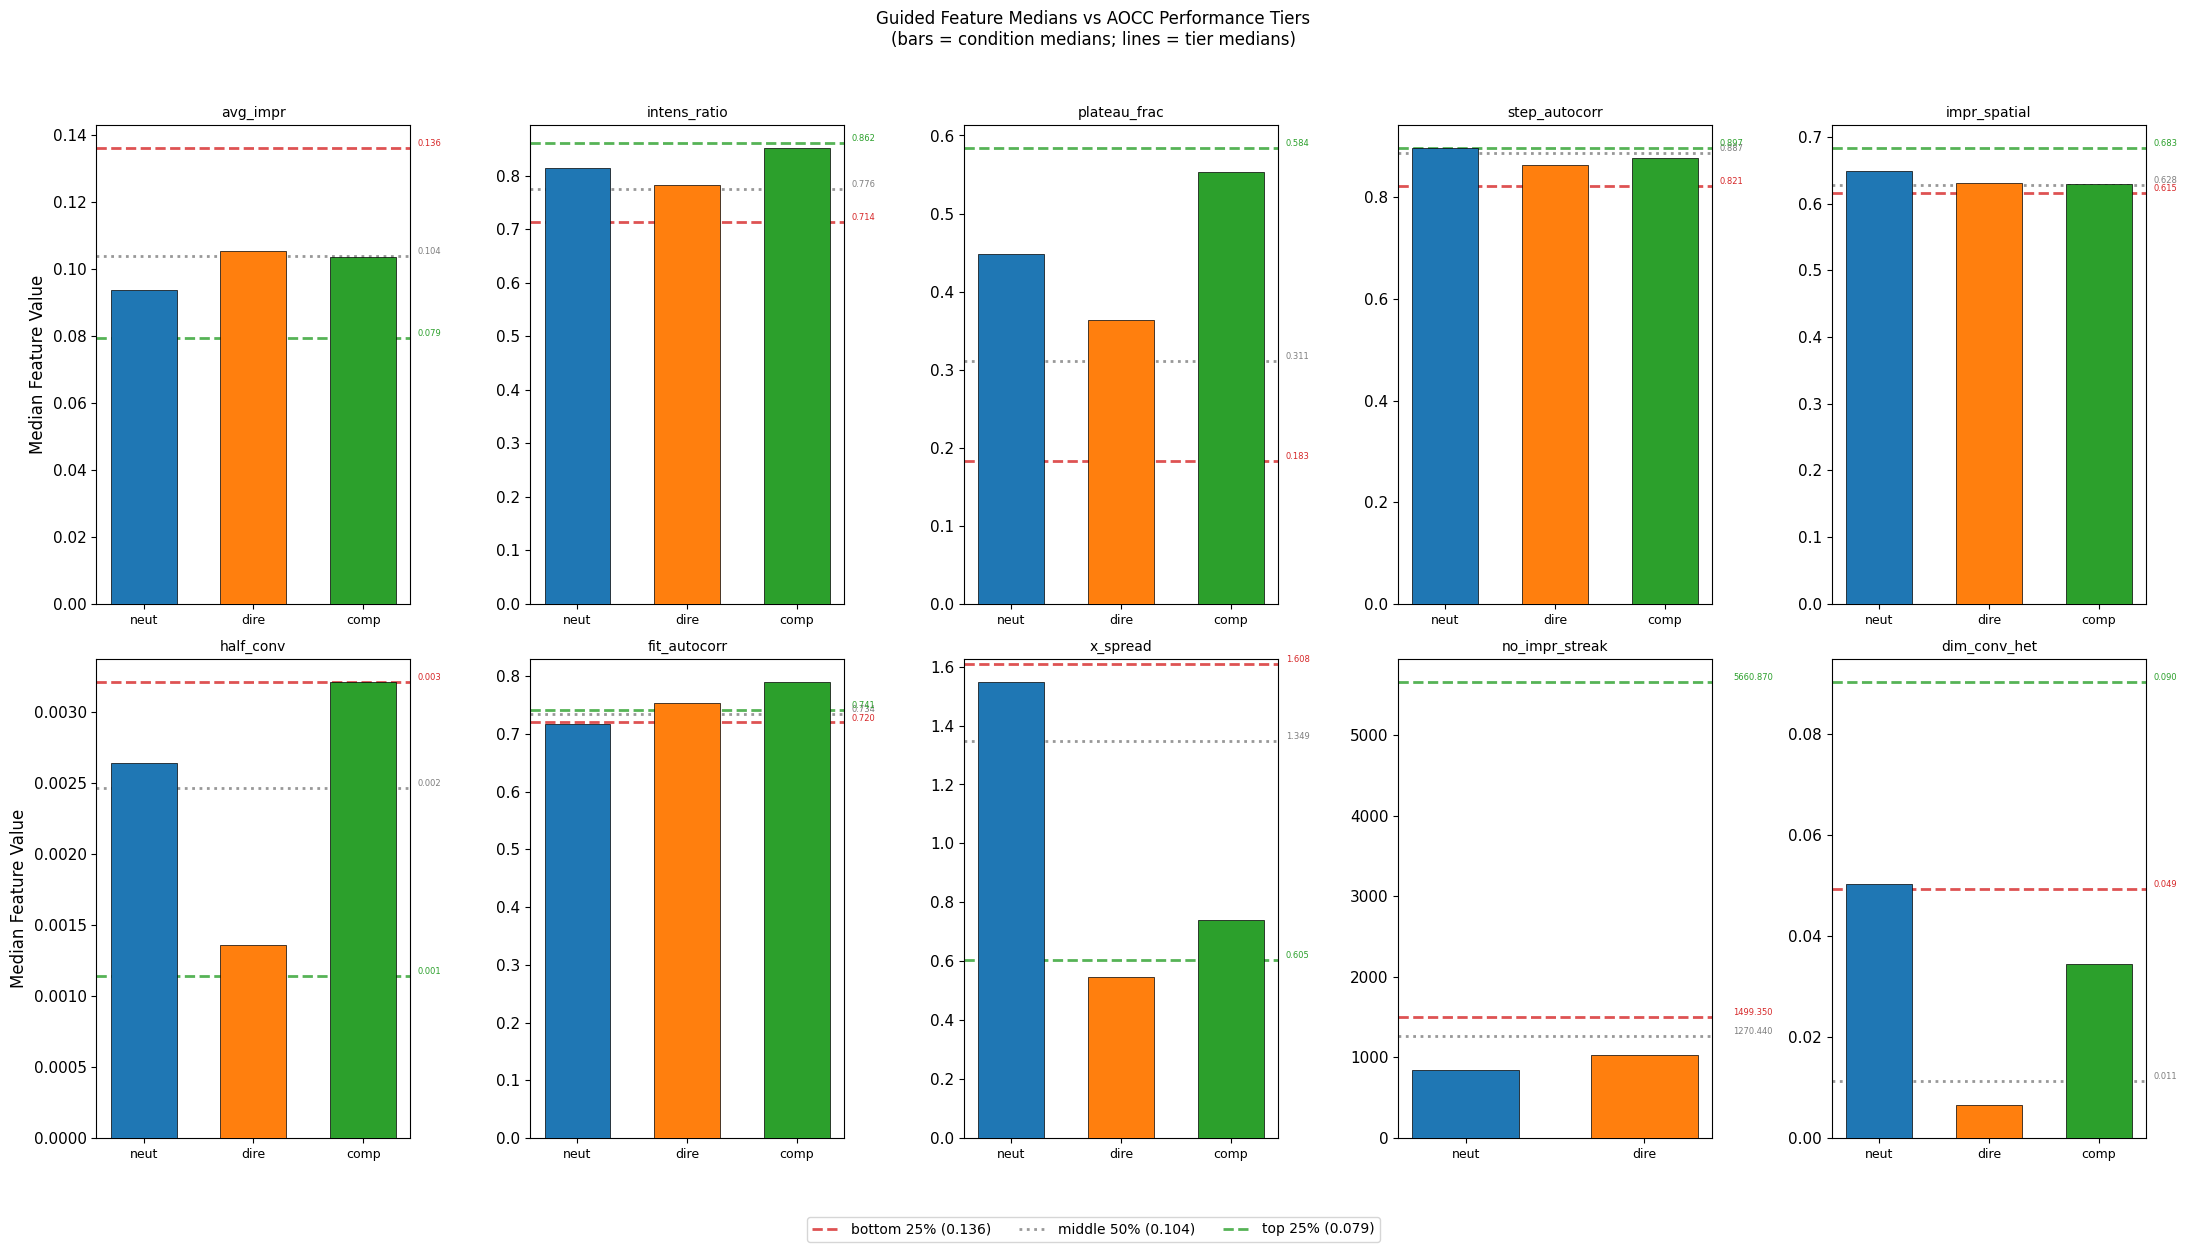


Median feature value by AOCC tier vs format:
                                      Feature    Bot25%    Mid50%    Top25%  |   Neutral    Direct    Compar
--------------------------------------------------------------------------------------------------------------
                              avg_improvement    0.1362    0.1040    0.0793  |    0.0937    0.1053    0.1036
                        intensification_ratio    0.7135    0.7755    0.8615  |    0.8134    0.7831    0.8518
                     fitness_plateau_fraction    0.1826    0.3106    0.5841  |    0.4483    0.3636    0.5532
                    step_size_autocorrelation    0.8215    0.8869    0.8971  |    0.8972    0.8630    0.8769
              improvement_spatial_correlation    0.6153    0.6275    0.6834  |    0.6487    0.6300    0.6289
                        half_convergence_time    0.0032    0.0025    0.0011  |    0.0026    0.0014    0.0032
                      fitness_autocorrelation    0.7198    0.7340    0.7409  |  

In [12]:
# Compute AOCC percentile thresholds across ALL valid algorithms
all_fitness = bf_df["fitness"].dropna()
p25 = all_fitness.quantile(0.25)
p75 = all_fitness.quantile(0.75)

print(f"AOCC thresholds: bottom-25% < {p25:.4f} | middle 25-75% | top-25% >= {p75:.4f}")

tiers = {
    "bottom 25%": bf_df[bf_df["fitness"] < p25],
    "middle 50%": bf_df[(bf_df["fitness"] >= p25) & (bf_df["fitness"] < p75)],
    "top 25%":    bf_df[bf_df["fitness"] >= p75],
}
tier_colors = {"bottom 25%": "#d62728", "middle 50%": "#7f7f7f", "top 25%": "#2ca02c"}
tier_styles = {"bottom 25%": "--", "middle 50%": ":", "top 25%": "--"}

# 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(22, 12), sharey=False)
axes_flat = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        ax.set_visible(False)
        continue

    fmts = formats_for_feature(feat)
    fmt_medians = []
    for fmt in fmts:
        sub = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt)][col].dropna()
        fmt_medians.append(sub.median())

    x_pos = np.arange(len(fmts))
    ax.bar(x_pos, fmt_medians, color=[FORMAT_COLORS[f] for f in fmts],
           edgecolor="black", linewidth=0.5, width=0.6, zorder=3)

    for tier_name, tier_df in tiers.items():
        tier_med = tier_df[col].dropna().median()
        ax.axhline(y=tier_med, color=tier_colors[tier_name],
                   linestyle=tier_styles[tier_name], linewidth=2, alpha=0.8,
                   label=f"{tier_name} ({tier_med:.3f})" if idx == 0 else None, zorder=2)
        ax.text(len(fmts) - 0.5, tier_med, f"{tier_med:.3f}",
                fontsize=6, color=tier_colors[tier_name], va="bottom", ha="left")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f[:4] for f in fmts], fontsize=9)
    ax.set_title(FEATURE_SHORT[feat], fontsize=10)
    if idx % 5 == 0:
        ax.set_ylabel("Median Feature Value")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.02), frameon=True)
fig.suptitle("Guided Feature Medians vs AOCC Performance Tiers\n"
             "(bars = condition medians; lines = tier medians)", fontsize=12, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

# Summary table
print("\nMedian feature value by AOCC tier vs format:")
print(f"{'Feature':>45s}  {'Bot25%':>8s}  {'Mid50%':>8s}  {'Top25%':>8s}  |  {'Neutral':>8s}  {'Direct':>8s}  {'Compar':>8s}")
print("-" * 110)
for feat in FEATURES:
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        continue
    tier_vals = {t: tiers[t][col].dropna().median() for t in tiers}
    fmts = formats_for_feature(feat)
    fmt_vals = {fmt: bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt)][col].median() for fmt in fmts}
    fmt_str = "  ".join(f"{fmt_vals.get(f, float('nan')):8.4f}" for f in FORMATS)
    print(f"{feat:>45s}  {tier_vals['bottom 25%']:8.4f}  {tier_vals['middle 50%']:8.4f}  "
          f"{tier_vals['top 25%']:8.4f}  |  {fmt_str}")

## 12. AOCC-Matched Behavioral Comparison
Control for algorithm quality: within AOCC bands, do formats produce behaviorally different algorithms?

AOCC band thresholds: bottom-25% < 0.5540 | middle 25-75% | top-25% >= 0.7835


NameError: name 'TOP5_FEATURES' is not defined

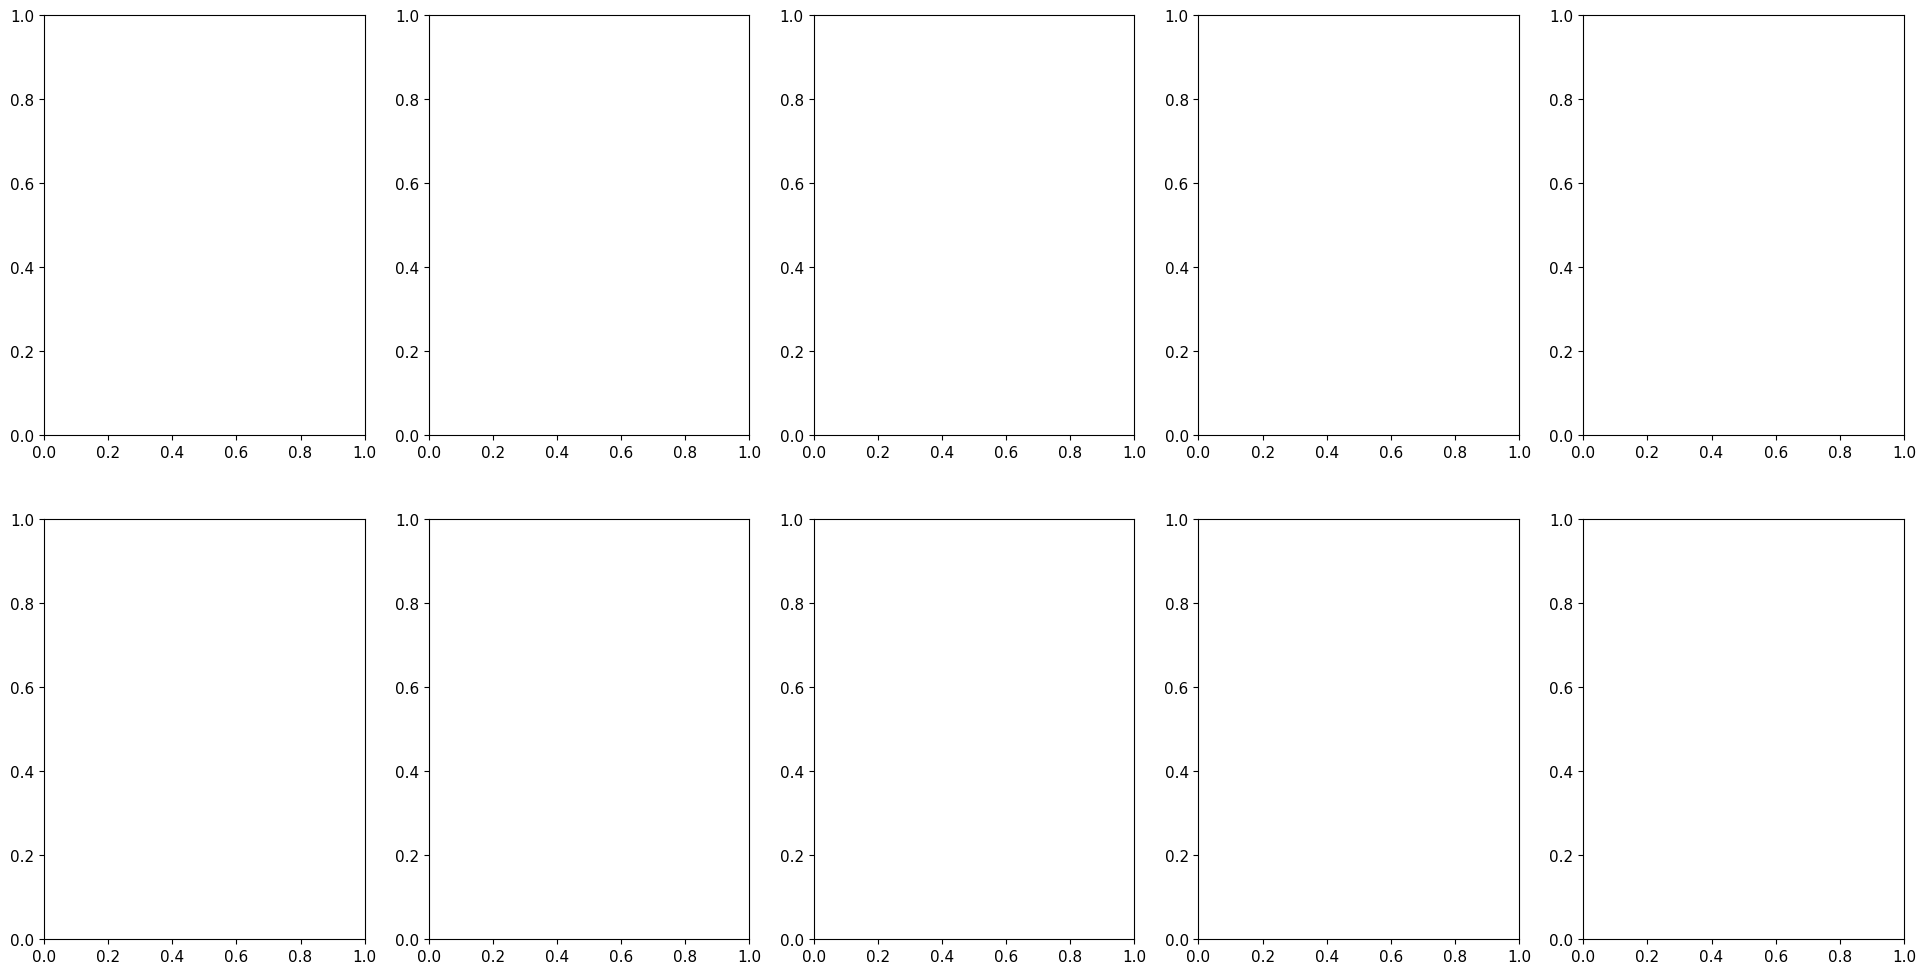

In [13]:
# AOCC bands based on percentile tiers
p25 = bf_df["fitness"].dropna().quantile(0.25)
p75 = bf_df["fitness"].dropna().quantile(0.75)

bands = [
    (f"bottom 25% (<{p25:.3f})", 0.0, p25),
    (f"middle 50% ({p25:.3f}-{p75:.3f})", p25, p75),
    (f"top 25% (>={p75:.3f})", p75, 1.0),
]
print(f"AOCC band thresholds: bottom-25% < {p25:.4f} | middle 25-75% | top-25% >= {p75:.4f}")

# 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(24, 12), sharey=False)
axes_flat = axes.flatten()

sig_results = []

for idx, feat in enumerate(FEATURES):
    ax = axes_flat[idx]
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        ax.set_visible(False)
        continue

    fmts = formats_for_feature(feat)
    band_idx = 0
    xticks = []
    xticklabels = []

    for band_name, lo, hi in bands:
        band_data = {}
        for fmt in fmts:
            sub = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt) &
                        (bf_df["fitness"] >= lo) & (bf_df["fitness"] < hi)]
            band_data[fmt] = sub[col].dropna().values

        if min(len(band_data[f]) for f in fmts) < 5:
            band_idx += 1
            continue

        # KW test
        kw_stat, kw_p = stats.kruskal(*[band_data[f] for f in fmts])
        sig_results.append({"feature": feat, "band": band_name, "kw_p": kw_p,
                           "borda": "top-5" if feat in TOP5_FEATURES else "bottom-5"})

        # Bars
        width = 0.25
        base_x = band_idx * 1.2
        for i, fmt in enumerate(fmts):
            x = base_x + i * width
            med = np.median(band_data[fmt])
            ax.bar(x, med, width, color=FORMAT_COLORS[fmt], edgecolor="black",
                   linewidth=0.5, zorder=3)

        xticks.append(base_x + width * (len(fmts) - 1) / 2)
        # Short label
        label = band_name.split("(")[0].strip()
        sig_mark = "*" if kw_p < 0.05 else ""
        xticklabels.append(f"{label}{sig_mark}")
        band_idx += 1

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=7, rotation=30, ha="right")
    title_color = "#1a5276" if feat in TOP5_FEATURES else "#7d3c98"
    ax.set_title(FEATURE_SHORT[feat], fontsize=10, color=title_color)
    if idx % 5 == 0:
        ax.set_ylabel("Median Feature Value")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=FORMAT_COLORS[f], edgecolor="black", label=f) for f in FORMATS]
axes_flat[-1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")

fig.suptitle("AOCC-Matched Comparison: Feature Values by Format Within Quality Bands\n"
             "(bottom 25% / middle 50% / top 25%; * = significant KW test, p<0.05)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary
sig_df = pd.DataFrame(sig_results)
n_sig = (sig_df["kw_p"] < 0.05).sum()
n_total = len(sig_df)
print(f"\n{n_sig}/{n_total} feature × band combinations show significant format effect (p<0.05)")

for borda in ["top-5", "bottom-5"]:
    sub = sig_df[sig_df["borda"] == borda]
    ns = (sub["kw_p"] < 0.05).sum()
    nt = len(sub)
    print(f"  {borda}: {ns}/{nt} significant")

print(f"\n{'Feature':>45s}  {'Band':>25s}  {'Borda':>7s}  {'KW p':>10s}")
print("-" * 95)
for _, row in sig_df.iterrows():
    sig = "*" if row["kw_p"] < 0.05 else ""
    print(f"{row['feature']:>45s}  {row['band']:>25s}  {row['borda']:>7s}  {row['kw_p']:10.4f}{sig}")

## 13. Steerability Ranking & AOCC-Correlation Analysis
Which features are most steerable? Does the feature's AOCC-correlation strength predict how much feedback formats affect performance?

In [ ]:
# Build steerability summary per feature
steer_summary_rows = []

for feat in FEATURES:
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        continue

    rho = abs(correlations[feat]["rho"])
    stat_row = [r for r in stat_rows if r["feature"] == feat][0]
    kw_p = stat_row["kw_p"]
    n_aocc = best[(best["feature"] == feat) & (best["format"] == "neutral")]["best_aocc"].mean()

    feat_sig = sig_df[sig_df["feature"] == feat]
    n_sig_bands = (feat_sig["kw_p"] < 0.05).sum()
    n_bands = len(feat_sig)

    feat_steer = steer_non_neutral[steer_non_neutral["feature"] == feat]
    n_correct_agg = (feat_steer["correct"] == "YES").sum()
    n_total_agg = len(feat_steer)

    fmts = formats_for_feature(feat)
    fmt_means = {f: best[(best["feature"] == feat) & (best["format"] == f)]["best_aocc"].mean() for f in fmts}
    worst_fmt = min(fmt_means, key=fmt_means.get)
    degradation = fmt_means["neutral"] - fmt_means[worst_fmt]

    steer_summary_rows.append({
        "feature": feat, "|rho|": rho, "kw_p": kw_p,
        "neutral_aocc": n_aocc, "steer_correct": f"{n_correct_agg}/{n_total_agg}",
        "sig_bands": f"{n_sig_bands}/{n_bands}", "degradation": degradation,
        "worst_format": worst_fmt,
    })

steer_summary = pd.DataFrame(steer_summary_rows).sort_values("|rho|", ascending=False)

print("Feature Steerability Summary (sorted by |AOCC correlation|):")
print("=" * 130)
print(f"{'Feature':>45s}  {'|rho|':>6s}  {'KW p':>8s}  {'Neut AOCC':>9s}  "
      f"{'Steer OK':>9s}  {'Sig Bands':>9s}  {'Degrad':>8s}  {'Worst Fmt':>10s}")
print("-" * 130)
for _, r in steer_summary.iterrows():
    sig = "*" if r["kw_p"] < 0.05 else ""
    print(f"{r['feature']:>45s}  {r['|rho|']:6.3f}  {r['kw_p']:8.4f}{sig}  "
          f"{r['neutral_aocc']:9.4f}  {r['steer_correct']:>9s}  {r['sig_bands']:>9s}  "
          f"{r['degradation']:+8.4f}  {r['worst_format']:>10s}")

# Scatter: |rho| vs format effect (KW H-statistic)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

rhos = [abs(correlations[f]["rho"]) for f in FEATURES if f in correlations]
kw_hs = [r["kw_H"] for r in stat_rows]
feat_labels_plot = [FEATURE_SHORT[f] for f in FEATURES]

ax1.scatter(rhos, kw_hs, s=80, edgecolor="black", linewidth=0.5, zorder=3, color="#1f77b4")
for i, feat in enumerate(FEATURES):
    ax1.annotate(feat_labels_plot[i], (rhos[i], kw_hs[i]), fontsize=8,
                 xytext=(5, 5), textcoords="offset points")
ax1.set_xlabel("|Spearman rho| (feature-AOCC correlation)")
ax1.set_ylabel("Kruskal-Wallis H (format effect on AOCC)")
ax1.set_title("Does AOCC-correlation predict format sensitivity?")
ax1.axhline(y=5.99, color="red", linestyle="--", alpha=0.5, label="KW critical (p=0.05, df=2)")
ax1.legend(fontsize=9)
rho_corr, p_corr = stats.spearmanr(rhos, kw_hs)
ax1.text(0.02, 0.98, f"Spearman r={rho_corr:.3f}, p={p_corr:.3f}",
         transform=ax1.transAxes, va="top", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Scatter: |rho| vs neutral AOCC
neutral_aoccs = [best[(best["feature"] == f) & (best["format"] == "neutral")]["best_aocc"].mean() for f in FEATURES]
ax2.scatter(rhos, neutral_aoccs, s=80, edgecolor="black", linewidth=0.5, zorder=3, color="#1f77b4")
for i, feat in enumerate(FEATURES):
    ax2.annotate(feat_labels_plot[i], (rhos[i], neutral_aoccs[i]), fontsize=8,
                 xytext=(5, 5), textcoords="offset points")
ax2.set_xlabel("|Spearman rho| (feature-AOCC correlation)")
ax2.set_ylabel("Neutral Format Mean AOCC")
ax2.set_title("Does AOCC-correlation predict neutral performance?")
ax2.axhline(y=vanilla_mean, color="red", linestyle="--", alpha=0.5, label=f"Vanilla ({vanilla_mean:.3f})")
ax2.legend(fontsize=9)
rho_corr2, p_corr2 = stats.spearmanr(rhos, neutral_aoccs)
ax2.text(0.02, 0.98, f"Spearman r={rho_corr2:.3f}, p={p_corr2:.3f}",
         transform=ax2.transAxes, va="top", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
plt.show()

## 14. AOCC-Matched Steering Direction Analysis
Within AOCC quality bands, does feedback push the guided feature in the right direction?
This is the key test: controlling for algorithm quality, does prescriptive feedback reliably steer behavior?

In [ ]:
# Within each AOCC band, check steering direction per feature per format
# Re-uses `bands` from Section 12
band_steer_rows = []

for feat in FEATURES:
    col = f"bf_{feat}"
    if col not in bf_df.columns:
        continue
    desired = correlations[feat]["advice_dir"]
    fmts = formats_for_feature(feat)

    for band_name, lo, hi in bands:
        band_data = {}
        for fmt in fmts:
            sub = bf_df[(bf_df["feature"] == feat) & (bf_df["format"] == fmt) &
                        (bf_df["fitness"] >= lo) & (bf_df["fitness"] < hi)]
            band_data[fmt] = sub[col].dropna()

        if len(band_data["neutral"]) < 5:
            continue

        neutral_med = band_data["neutral"].median()

        for fmt in fmts:
            if fmt == "neutral" or len(band_data[fmt]) < 5:
                continue
            fmt_med = band_data[fmt].median()
            diff = fmt_med - neutral_med
            if desired == "higher":
                correct = "RIGHT" if diff > 0 else "WRONG"
            else:
                correct = "RIGHT" if diff < 0 else "WRONG"

            band_steer_rows.append({
                "feature": feat, "band": band_name, "format": fmt,
                "neutral_med": neutral_med, "fmt_med": fmt_med,
                "diff": diff, "correct": correct,
            })

band_steer_df = pd.DataFrame(band_steer_rows)

# Tally
for fmt in ["directional", "comparative"]:
    sub = band_steer_df[band_steer_df["format"] == fmt]
    n_right = (sub["correct"] == "RIGHT").sum()
    n_total = len(sub)
    print(f"{fmt}: {n_right}/{n_total} right ({n_right/n_total*100:.0f}%)")

# Heatmap: feature × band, colored by steering direction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

for ax, fmt in zip([ax1, ax2], ["directional", "comparative"]):
    sub = band_steer_df[band_steer_df["format"] == fmt]
    if sub.empty:
        ax.set_visible(False)
        continue

    band_names = [b[0] for b in bands]
    matrix = np.full((len(FEATURES), len(band_names)), np.nan)
    correct_matrix = np.full((len(FEATURES), len(band_names)), "", dtype=object)

    for _, row in sub.iterrows():
        fi = FEATURES.index(row["feature"])
        bi = band_names.index(row["band"])
        matrix[fi, bi] = row["diff"]
        correct_matrix[fi, bi] = row["correct"]

    color_matrix = np.zeros((*matrix.shape, 3))
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if correct_matrix[i, j] == "RIGHT":
                color_matrix[i, j] = [0.2, 0.8, 0.2]
            elif correct_matrix[i, j] == "WRONG":
                color_matrix[i, j] = [0.8, 0.2, 0.2]
            else:
                color_matrix[i, j] = [0.9, 0.9, 0.9]

    ax.imshow(color_matrix, aspect="auto")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f"{matrix[i, j]:+.3f}", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")

    ax.set_xticks(range(len(band_names)))
    ax.set_xticklabels(["bot 25%", "mid 50%", "top 25%"], fontsize=9)
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels([FEATURE_SHORT[f] for f in FEATURES], fontsize=9)
    ax.set_title(f"{fmt.title()}: Steering Direction by Band\n(green = right, red = wrong)", fontsize=11)

plt.tight_layout()
plt.show()

# Full table
print(f"\n{'Feature':>45s}  {'Band':>15s}  {'Format':>12s}  {'Diff':>10s}  {'Dir':>6s}")
print("-" * 95)
for _, r in band_steer_df.sort_values(["feature", "band", "format"]).iterrows():
    short_band = r["band"].split("(")[0].strip()
    print(f"{r['feature']:>45s}  {short_band:>15s}  {r['format']:>12s}  "
          f"{r['diff']:+10.4f}  {r['correct']:>6s}")